In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Project folders
PROCESSED_DIR = "../data/processed"
RAW_DIR = "../data/raw"
OUTPUT_DIR = "../outputs"
CHART_DIR = "../outputs/charts"

# Create output folders
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(CHART_DIR, exist_ok=True)

print("Performance Analytics environment ready.")

Performance Analytics environment ready.


In [2]:
nav_path = os.path.join(
    PROCESSED_DIR,
    "nav_history_clean.csv"
)

nav = pd.read_csv(nav_path)

print("Shape:", nav.shape)

print("\nColumns:")
print(nav.columns.tolist())

display(nav.head())

Shape: (46000, 3)

Columns:
['amfi_code', 'date', 'nav']


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav.columns = (
    nav.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

nav["date"] = pd.to_datetime(
    nav["date"],
    errors="coerce"
)

nav["nav"] = pd.to_numeric(
    nav["nav"],
    errors="coerce"
)

nav = nav.dropna(
    subset=["amfi_code", "date", "nav"]
)

nav = nav[nav["nav"] > 0]

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav = nav.drop_duplicates(
    subset=["amfi_code", "date"],
    keep="last"
)

print("Clean NAV shape:", nav.shape)

print(
    "Number of schemes:",
    nav["amfi_code"].nunique()
)

print(
    "Date range:",
    nav["date"].min(),
    "to",
    nav["date"].max()
)

Clean NAV shape: (46000, 3)
Number of schemes: 40
Date range: 2022-01-03 00:00:00 to 2026-05-29 00:00:00


In [10]:
print("=" * 70)
print("STEP 4 - DAILY RETURN CALCULATION")
print("=" * 70)

# Make sure data is sorted correctly
nav = nav.sort_values(["amfi_code", "date"]).copy()

# Calculate daily return (group by amfi_code)
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

# Display first few rows
print("\nSample daily returns:")
print(
    nav[
        ["date", "amfi_code", "nav", "daily_return"]
    ].head(15)
)

# Number of schemes
print("\nNumber of schemes:", nav["amfi_code"].nunique())

# Number of schemes
print("\nNumber of schemes:", nav["amfi_code"].nunique())

# Count daily return records
print("Total NAV records:", len(nav))

# Missing daily returns occur for the first observation of each fund
print(
    "Missing daily returns:",
    nav["daily_return"].isna().sum()
)

# Remove missing values for statistical analysis
returns = nav.dropna(subset=["daily_return"]).copy()

print(
    "Valid daily return records:",
    len(returns)
)

# ------------------------------------------------------------
# Distribution statistics
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("DAILY RETURN DISTRIBUTION")
print("=" * 70)

print(
    returns["daily_return"].describe()
)

# Check extreme returns
print("\nMinimum daily return:")
print(returns["daily_return"].min())

print("\nMaximum daily return:")
print(returns["daily_return"].max())

print("\nMean daily return:")
print(returns["daily_return"].mean())

print("\nDaily return standard deviation:")
print(returns["daily_return"].std())

# ------------------------------------------------------------
# Save daily returns
# ------------------------------------------------------------

output_file = "data/processed/daily_returns.csv"

# ensure processed dir exists and save using PROCESSED_DIR
os.makedirs(PROCESSED_DIR, exist_ok=True)
output_file = os.path.join(PROCESSED_DIR, "daily_returns.csv")
returns.to_csv(output_file, index=False)

print("\n" + "=" * 70)
print("DAILY RETURNS CALCULATION COMPLETED")
print("=" * 70)

print("Saved to:", output_file)

STEP 4 - DAILY RETURN CALCULATION

Sample daily returns:
         date  amfi_code       nav  daily_return
0  2022-01-03     100016  520.4608           NaN
1  2022-01-04     100016  515.0971     -0.010306
2  2022-01-05     100016  521.7239      0.012865
3  2022-01-06     100016  515.7880     -0.011377
4  2022-01-07     100016  515.1639     -0.001210
5  2022-01-10     100016  510.7136     -0.008639
6  2022-01-11     100016  513.5542      0.005562
7  2022-01-12     100016  512.3195     -0.002404
8  2022-01-13     100016  510.2445     -0.004050
9  2022-01-14     100016  514.3636      0.008073
10 2022-01-17     100016  514.7627      0.000776
11 2022-01-18     100016  517.3803      0.005085
12 2022-01-19     100016  513.1866     -0.008106
13 2022-01-20     100016  507.1294     -0.011803
14 2022-01-21     100016  507.8710      0.001462

Number of schemes: 40

Number of schemes: 40
Total NAV records: 46000
Missing daily returns: 40
Valid daily return records: 45960

DAILY RETURN DISTRIBUTION
c

In [13]:
# ============================================================
# STEP 5: CAGR ANALYSIS - 1 YEAR, 3 YEAR, 5 YEAR
# ============================================================

print("=" * 70)
print("STEP 5 - CAGR ANALYSIS")
print("=" * 70)

import pandas as pd
import numpy as np

# Make sure NAV data is sorted
# ensure we have a 'scheme' column; original data uses 'amfi_code'
nav = nav.sort_values(["amfi_code", "date"]).copy()
if "scheme" not in nav.columns:
    nav["scheme"] = nav["amfi_code"]

# ------------------------------------------------------------
# CAGR calculation function
# ------------------------------------------------------------

def calculate_cagr(start_nav, end_nav, years):
    if pd.isna(start_nav) or pd.isna(end_nav):
        return np.nan

    if start_nav <= 0 or end_nav <= 0:
        return np.nan

    return (end_nav / start_nav) ** (1 / years) - 1


# ------------------------------------------------------------
# Calculate CAGR for each fund
# ------------------------------------------------------------

cagr_results = []

for scheme in nav["scheme"].unique():

    fund = nav[nav["scheme"] == scheme].copy()
    fund = fund.sort_values("date")

    end_date = fund["date"].max()
    end_nav = fund.iloc[-1]["nav"]

    # 1 year
    target_1y = end_date - pd.DateOffset(years=1)
    data_1y = fund[fund["date"] <= target_1y]

    if len(data_1y) > 0:
        start_1y = data_1y.iloc[-1]["nav"]
        cagr_1y = calculate_cagr(start_1y, end_nav, 1)
    else:
        cagr_1y = np.nan

    # 3 years
    target_3y = end_date - pd.DateOffset(years=3)
    data_3y = fund[fund["date"] <= target_3y]

    if len(data_3y) > 0:
        start_3y = data_3y.iloc[-1]["nav"]
        cagr_3y = calculate_cagr(start_3y, end_nav, 3)
    else:
        cagr_3y = np.nan

    # 5 years
    target_5y = end_date - pd.DateOffset(years=5)
    data_5y = fund[fund["date"] <= target_5y]

    if len(data_5y) > 0:
        start_5y = data_5y.iloc[-1]["nav"]
        cagr_5y = calculate_cagr(start_5y, end_nav, 5)
    else:
        cagr_5y = np.nan

    cagr_results.append({
        "scheme": scheme,
        "CAGR_1Y": cagr_1y,
        "CAGR_3Y": cagr_3y,
        "CAGR_5Y": cagr_5y
    })


# Convert results into DataFrame
cagr_df = pd.DataFrame(cagr_results)


# ------------------------------------------------------------
# Convert to percentage
# ------------------------------------------------------------

cagr_df["CAGR_1Y_%"] = cagr_df["CAGR_1Y"] * 100
cagr_df["CAGR_3Y_%"] = cagr_df["CAGR_3Y"] * 100
cagr_df["CAGR_5Y_%"] = cagr_df["CAGR_5Y"] * 100


# ------------------------------------------------------------
# Display comparison table
# ------------------------------------------------------------

print("\nCAGR COMPARISON - ALL FUNDS")
print("=" * 70)

print(
    cagr_df[
        [
            "scheme",
            "CAGR_1Y_%",
            "CAGR_3Y_%",
            "CAGR_5Y_%"
        ]
    ].round(2).to_string(index=False)
)


# ------------------------------------------------------------
# Save CAGR results
# ------------------------------------------------------------

output_file = os.path.join(PROCESSED_DIR, "cagr_comparison.csv")
os.makedirs(PROCESSED_DIR, exist_ok=True)
cagr_df.to_csv(output_file, index=False)

print("\n" + "=" * 70)
print("CAGR ANALYSIS COMPLETED")
print("=" * 70)

print("Number of funds:", len(cagr_df))

print(
    "Saved to: data/processed/cagr_comparison.csv"
)

STEP 5 - CAGR ANALYSIS

CAGR COMPARISON - ALL FUNDS
 scheme  CAGR_1Y_%  CAGR_3Y_%  CAGR_5Y_%
 100016      -2.22       1.29        NaN
 100025       3.70       3.92        NaN
 100033      53.23      32.44        NaN
 101206      47.92      28.97        NaN
 101207     -23.99      -4.15        NaN
 101208       7.24       6.32        NaN
 102885      20.21      19.67        NaN
 102886     -16.80      -0.77        NaN
 102887      13.58      25.56        NaN
 118632      33.98      22.65        NaN
 118633      25.54      21.09        NaN
 118634      15.81       8.01        NaN
 118635      22.49      20.01        NaN
 118636      10.45       4.06        NaN
 119092       1.61       0.53        NaN
 119093      19.77      20.82        NaN
 119094      22.26      35.11        NaN
 119095     -42.80     -11.71        NaN
 119120       5.52       5.84        NaN
 119551      60.44      30.46        NaN
 119552       5.71      16.27        NaN
 119598      82.78      26.67        NaN
 1195

In [17]:
# ============================================================
# STEP 6: SHARPE RATIO ANALYSIS
# ============================================================

print("=" * 70)
print("STEP 6 - SHARPE RATIO ANALYSIS")
print("=" * 70)

import numpy as np
import pandas as pd

# Risk-free rate = 6.5%
RISK_FREE_RATE = 0.065

# Trading days per year
TRADING_DAYS = 252

# Daily risk-free rate
DAILY_RF = (1 + RISK_FREE_RATE) ** (1 / TRADING_DAYS) - 1

print("Annual Risk-Free Rate:", RISK_FREE_RATE * 100, "%")
print("Daily Risk-Free Rate:", DAILY_RF)


# ------------------------------------------------------------
# Ensure 'scheme' exists in returns
# ------------------------------------------------------------
if "scheme" not in returns.columns:
    returns["scheme"] = returns["amfi_code"]


# ------------------------------------------------------------
# Calculate Sharpe Ratio for every fund
# ------------------------------------------------------------

sharpe_results = []

for scheme in returns["scheme"].unique():

    fund_returns = returns[
        returns["scheme"] == scheme
    ]["daily_return"].dropna()

    # Excess daily returns
    excess_returns = fund_returns - DAILY_RF

    # Mean excess return
    mean_excess_return = excess_returns.mean()

    # Standard deviation
    std_return = fund_returns.std()

    # Annualized Sharpe Ratio
    if std_return != 0:
        sharpe = (
            mean_excess_return /
            std_return
        ) * np.sqrt(TRADING_DAYS)
    else:
        sharpe = np.nan

    sharpe_results.append({
        "scheme": scheme,
        "mean_daily_return": fund_returns.mean(),
        "daily_std": std_return,
        "sharpe_ratio": sharpe
    })


# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

sharpe_df = pd.DataFrame(sharpe_results)


# ------------------------------------------------------------
# Rank funds
# ------------------------------------------------------------

sharpe_df["Sharpe_Rank"] = (
    sharpe_df["sharpe_ratio"]
    .rank(
        ascending=False,
        method="min"
    )
)


# ------------------------------------------------------------
# Sort best to worst
# ------------------------------------------------------------

sharpe_df = sharpe_df.sort_values(
    "sharpe_ratio",
    ascending=False
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("\nSHARPE RATIO RANKING")
print("=" * 70)

print(
    sharpe_df[
        [
            "scheme",
            "mean_daily_return",
            "daily_std",
            "sharpe_ratio",
            "Sharpe_Rank"
        ]
    ].round(4).to_string(index=False)
)


# ------------------------------------------------------------
# Top 10 funds
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP 10 FUNDS BY SHARPE RATIO")
print("=" * 70)

print(
    sharpe_df[
        [
            "scheme",
            "sharpe_ratio"
        ]
    ].head(10).round(4).to_string(index=False)
)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------

os.makedirs(PROCESSED_DIR, exist_ok=True)
output_path = os.path.join(PROCESSED_DIR, "sharpe_ratio.csv")
sharpe_df.to_csv(output_path, index=False)


print("\n" + "=" * 70)
print("SHARPE RATIO ANALYSIS COMPLETED")
print("=" * 70)

print("Number of funds:", len(sharpe_df))

print(
    "Saved to: data/processed/sharpe_ratio.csv"
)

STEP 6 - SHARPE RATIO ANALYSIS
Annual Risk-Free Rate: 6.5 %
Daily Risk-Free Rate: 0.00024993122427763304

SHARPE RATIO RANKING
 scheme  mean_daily_return  daily_std  sharpe_ratio  Sharpe_Rank
 148567             0.0011     0.0089        1.4625          1.0
 120843             0.0011     0.0100        1.3194          2.0
 148569             0.0011     0.0111        1.2463          3.0
 119551             0.0009     0.0087        1.2229          4.0
 120505             0.0012     0.0122        1.1906          5.0
 149323             0.0011     0.0112        1.1435          6.0
 100033             0.0011     0.0119        1.1044          7.0
 118632             0.0009     0.0089        1.0959          8.0
 101206             0.0009     0.0092        1.0411          9.0
 120504             0.0008     0.0090        1.0406         10.0
 119094             0.0010     0.0122        1.0086         11.0
 119552             0.0008     0.0088        0.9678         12.0
 149324             0.0012  

In [19]:
# ============================================================
# STEP 7: SORTINO RATIO ANALYSIS
# ============================================================

print("=" * 70)
print("STEP 7 - SORTINO RATIO ANALYSIS")
print("=" * 70)

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

RISK_FREE_RATE = 0.065
TRADING_DAYS = 252

# Convert annual risk-free rate to daily rate
DAILY_RF = (1 + RISK_FREE_RATE) ** (1 / TRADING_DAYS) - 1

print("Annual Risk-Free Rate:", RISK_FREE_RATE * 100, "%")
print("Daily Risk-Free Rate:", DAILY_RF)


# ------------------------------------------------------------
# Calculate Sortino Ratio for every fund
# ------------------------------------------------------------

sortino_results = []

for scheme in returns["scheme"].unique():

    # Get fund daily returns
    fund_returns = returns[
        returns["scheme"] == scheme
    ]["daily_return"].dropna()

    # Excess returns over daily risk-free rate
    excess_returns = fund_returns - DAILY_RF

    # --------------------------------------------------------
    # Downside returns
    # Only returns below the risk-free rate are considered
    # --------------------------------------------------------

    downside_returns = excess_returns[
        excess_returns < 0
    ]

    # Downside deviation
    if len(downside_returns) > 0:
        downside_deviation = np.sqrt(
            np.mean(downside_returns ** 2)
        )
    else:
        downside_deviation = np.nan

    # Mean excess return
    mean_excess_return = excess_returns.mean()

    # Annualized Sortino Ratio
    if (
        downside_deviation != 0
        and not np.isnan(downside_deviation)
    ):
        sortino = (
            mean_excess_return /
            downside_deviation
        ) * np.sqrt(TRADING_DAYS)
    else:
        sortino = np.nan

    sortino_results.append({
        "scheme": scheme,
        "mean_daily_return": fund_returns.mean(),
        "downside_deviation": downside_deviation,
        "sortino_ratio": sortino
    })


# ------------------------------------------------------------
# Create DataFrame
# ------------------------------------------------------------

sortino_df = pd.DataFrame(sortino_results)


# ------------------------------------------------------------
# Rank funds
# ------------------------------------------------------------

sortino_df["Sortino_Rank"] = (
    sortino_df["sortino_ratio"]
    .rank(
        ascending=False,
        method="min"
    )
)


# ------------------------------------------------------------
# Sort best to worst
# ------------------------------------------------------------

sortino_df = sortino_df.sort_values(
    "sortino_ratio",
    ascending=False
)


# ------------------------------------------------------------
# Display complete ranking
# ------------------------------------------------------------

print("\nSORTINO RATIO RANKING")
print("=" * 70)

print(
    sortino_df[
        [
            "scheme",
            "mean_daily_return",
            "downside_deviation",
            "sortino_ratio",
            "Sortino_Rank"
        ]
    ].round(4).to_string(index=False)
)


# ------------------------------------------------------------
# Top 10 funds
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("TOP 10 FUNDS BY SORTINO RATIO")
print("=" * 70)

print(
    sortino_df[
        [
            "scheme",
            "sortino_ratio"
        ]
    ].head(10).round(4).to_string(index=False)
)


# ------------------------------------------------------------
# Save results
# ------------------------------------------------------------
os.makedirs("data/processed", exist_ok=True)

sortino_df.to_csv(
    os.path.join(PROCESSED_DIR, "sortino_ratio.csv"),
    index=False
)

print("\n" + "=" * 70)
print("SORTINO RATIO ANALYSIS COMPLETED")
print("=" * 70)

print("Number of funds:", len(sortino_df))

print(
    "Saved to: data/processed/sortino_ratio.csv"
)

STEP 7 - SORTINO RATIO ANALYSIS
Annual Risk-Free Rate: 6.5 %
Daily Risk-Free Rate: 0.00024993122427763304

SORTINO RATIO RANKING
 scheme  mean_daily_return  downside_deviation  sortino_ratio  Sortino_Rank
 148567             0.0011              0.0088         1.4777           1.0
 120843             0.0011              0.0095         1.3963           2.0
 148569             0.0011              0.0106         1.3149           3.0
 119551             0.0009              0.0083         1.2778           4.0
 120505             0.0012              0.0116         1.2500           5.0
 149323             0.0011              0.0111         1.1474           6.0
 100033             0.0011              0.0116         1.1335           7.0
 118632             0.0009              0.0087         1.1205           8.0
 101206             0.0009              0.0088         1.0846           9.0
 119094             0.0010              0.0116         1.0608          10.0
 120504             0.0008         

In [20]:
# ============================================================
# STEP 8.1: CHECK NIFTY 100 BENCHMARK DATA
# ============================================================

import os
import glob
import pandas as pd

print("=" * 70)
print("STEP 8.1 - FINDING NIFTY 100 BENCHMARK DATA")
print("=" * 70)

# Search the project for CSV files containing benchmark/index data
csv_files = glob.glob("data/**/*.csv", recursive=True)

print("\nCSV files found:")
for file in csv_files:
    print(file)

print("\n" + "=" * 70)
print("FILES THAT MAY CONTAIN NIFTY / BENCHMARK DATA")
print("=" * 70)

benchmark_files = [
    file for file in csv_files
    if any(
        word in os.path.basename(file).lower()
        for word in [
            "nifty",
            "benchmark",
            "index",
            "indices"
        ]
    )
]

for file in benchmark_files:
    print(file)

print("\nNumber of possible benchmark files:",
      len(benchmark_files))

STEP 8.1 - FINDING NIFTY 100 BENCHMARK DATA

CSV files found:

FILES THAT MAY CONTAIN NIFTY / BENCHMARK DATA

Number of possible benchmark files: 0


In [23]:
# ============================================================
# STEP 8.2 - CHECK NIFTY 100 BENCHMARK FILE
# ============================================================

benchmark_file = os.path.join(
    PROCESSED_DIR,
    "10_benchmark_indices_clean.csv"
)

if os.path.isfile(benchmark_file):
    benchmark = pd.read_csv(benchmark_file)
    loaded_successfully = True
else:
    benchmark = pd.DataFrame()
    loaded_successfully = False
    print(f"Benchmark file not found: {benchmark_file}")
    print("Please verify the benchmark file exists under PROCESSED_DIR.")

print("=" * 70)
print(
    "BENCHMARK FILE LOADED SUCCESSFULLY"
    if loaded_successfully
    else "BENCHMARK FILE NOT LOADED"
)
print("=" * 70)

print("\nShape:")
print(benchmark.shape)

print("\nColumn names:")
print(benchmark.columns.tolist())

print("\nFirst 5 rows:")
print(benchmark.head())

print("\nData types:")
print(benchmark.dtypes)

if not benchmark.empty:
    print("\nDate range:")
    print(
        benchmark.iloc[:, 0].min(),
        "to",
        benchmark.iloc[:, 0].max()
    )
else:
    print("\nNo benchmark date available.")

BENCHMARK FILE LOADED SUCCESSFULLY

Shape:
(8050, 3)

Column names:
['date', 'index_name', 'close_value']

First 5 rows:
         date index_name  close_value
0  2022-01-03    NIFTY50     17492.79
1  2022-01-04    NIFTY50     17689.64
2  2022-01-05    NIFTY50     17835.05
3  2022-01-06    NIFTY50     17878.51
4  2022-01-07    NIFTY50     17759.15

Data types:
date               str
index_name         str
close_value    float64
dtype: object

Date range:
2022-01-03 to 2026-05-29


In [25]:
# ==========================================
# STEP 9 - CHECK AVAILABLE BENCHMARK INDEXES
# ==========================================

print("Available benchmark indexes:")
print(benchmark["index_name"].unique())

print("\nNumber of records for each index:")
print(benchmark["index_name"].value_counts())

Available benchmark indexes:
<StringArray>
['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP', 'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT']
Length: 7, dtype: str

Number of records for each index:
index_name
NIFTY50            1150
NIFTY100           1150
NIFTY_MIDCAP150    1150
BSE_SMALLCAP       1150
NIFTY500           1150
CRISIL_LIQUID      1150
CRISIL_GILT        1150
Name: count, dtype: int64


In [29]:
# ==========================================
# STEP 10 - ALPHA & BETA CALCULATION
# ==========================================

import pandas as pd
import numpy as np
from scipy.stats import linregress

print("=" * 60)
print("STEP 10 - ALPHA & BETA ANALYSIS")
print("=" * 60)

# Make sure dates are datetime
nav["date"] = pd.to_datetime(nav["date"])
benchmark_df = benchmark.copy()
benchmark_df["date"] = pd.to_datetime(benchmark_df["date"])

# -------------------------------------------------
# 1. Prepare fund daily returns
# -------------------------------------------------

nav = nav.sort_values(["scheme", "date"])

nav["daily_return"] = (
    nav.groupby("scheme")["nav"]
    .pct_change()
)

# Remove missing returns
fund_returns = nav.dropna(
    subset=["daily_return"]
).copy()

print("Fund return data prepared.")
print("Number of funds:", fund_returns["scheme"].nunique())


# -------------------------------------------------
# 2. Prepare NIFTY 100 benchmark
# -------------------------------------------------

benchmark_df["index_name"] = (
    benchmark_df["index_name"]
    .astype(str)
    .str.upper()
    .str.replace(" ", "")
)

# Check available indexes
print("\nAvailable indexes:")
print(benchmark_df["index_name"].unique())

# Try NIFTY100 first
nifty100 = benchmark_df[
    benchmark_df["index_name"].str.contains("NIFTY100")
].copy()

# If NIFTY100 does not exist, use NIFTY50 as fallback
if nifty100.empty:

    print("\nNIFTY100 data not found.")
    print("Using NIFTY50 as benchmark for now.")

    nifty100 = benchmark_df[
        benchmark_df["index_name"].str.contains("NIFTY50")
    ].copy()

    benchmark_name = "NIFTY50"

else:

    benchmark_name = "NIFTY100"


# -------------------------------------------------
# 3. Calculate benchmark daily returns
# -------------------------------------------------

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100 = nifty100.dropna(
    subset=["benchmark_return"]
)

print("\nBenchmark selected:", benchmark_name)

print(
    "Benchmark rows:",
    len(nifty100)
)


# -------------------------------------------------
# 4. Merge fund returns with benchmark returns
# -------------------------------------------------

merged = pd.merge(
    fund_returns[
        ["date", "scheme", "daily_return"]
    ],
    nifty100[
        ["date", "benchmark_return"]
    ],
    on="date",
    how="inner"
)

print("\nMerged dataset shape:")
print(merged.shape)


# -------------------------------------------------
# 5. Calculate Alpha and Beta
# -------------------------------------------------

alpha_beta_results = []

for fund in merged["scheme"].unique():

    fund_data = merged[
        merged["scheme"] == fund
    ].dropna(
        subset=[
            "daily_return",
            "benchmark_return"
        ]
    )

    # Need sufficient observations
    if len(fund_data) < 30:
        continue

    regression = linregress(
        fund_data["benchmark_return"],
        fund_data["daily_return"]
    )

    beta = regression.slope

    daily_alpha = regression.intercept

    annual_alpha = daily_alpha * 252

    r_squared = regression.rvalue ** 2

    alpha_beta_results.append({
        "scheme": fund,
        "alpha": annual_alpha,
        "beta": beta,
        "r_squared": r_squared,
        "observations": len(fund_data)
    })


# -------------------------------------------------
# 6. Create result DataFrame
# -------------------------------------------------

alpha_beta_df = pd.DataFrame(
    alpha_beta_results
)

alpha_beta_df = alpha_beta_df.sort_values(
    "alpha",
    ascending=False
).reset_index(drop=True)


# -------------------------------------------------
# 7. Display results
# -------------------------------------------------

print("\n" + "=" * 60)
print("ALPHA & BETA RESULTS")
print("=" * 60)

print(
    alpha_beta_df.head(40).to_string(index=False)
)


# -------------------------------------------------
# 8. Save result
# -------------------------------------------------

alpha_beta_df.to_csv(
    "data/processed/alpha_beta.csv",
    index=False
)

print("\nAlpha/Beta analysis saved successfully.")

print(
    "\nFile created:"
)

print(
    "data/processed/alpha_beta.csv"
)

STEP 10 - ALPHA & BETA ANALYSIS
Fund return data prepared.
Number of funds: 40

Available indexes:
<StringArray>
['NIFTY50', 'NIFTY100', 'NIFTY_MIDCAP150', 'BSE_SMALLCAP', 'NIFTY500', 'CRISIL_LIQUID', 'CRISIL_GILT']
Length: 7, dtype: str

Benchmark selected: NIFTY100
Benchmark rows: 1149

Merged dataset shape:
(45960, 4)

ALPHA & BETA RESULTS
 scheme    alpha      beta    r_squared  observations
 119598 0.303370 -0.023196 1.414258e-04          1149
 149324 0.300579  0.011455 3.532991e-05          1149
 120505 0.292636  0.000549 1.345534e-07          1149
 148569 0.282704  0.018134 1.748889e-04          1149
 120843 0.273305 -0.022830 3.430543e-04          1149
 100033 0.271954  0.005104 1.206652e-05          1149
 148567 0.269838  0.023684 4.625437e-04          1149
 149323 0.265986 -0.002523 3.357978e-06          1149
 119094 0.260767 -0.066265 1.936879e-03          1149
 119551 0.232010 -0.031751 8.869789e-04          1149
 118632 0.218294 -0.008354 5.791756e-05          1149
 101206

In [32]:
# ==========================================
# STEP 11 - MAXIMUM DRAWDOWN ANALYSIS
# ==========================================

import pandas as pd
import numpy as np

print("=" * 60)
print("STEP 11 - MAXIMUM DRAWDOWN ANALYSIS")
print("=" * 60)

# Make sure NAV data is sorted
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["scheme", "date"]).copy()

# ------------------------------------------
# Calculate running maximum NAV
# ------------------------------------------

nav["running_max"] = (
    nav.groupby("scheme")["nav"]
    .cummax()
)

# ------------------------------------------
# Calculate drawdown
# ------------------------------------------

nav["drawdown"] = (
    nav["nav"] / nav["running_max"]
) - 1

# ------------------------------------------
# Find maximum drawdown for each fund
# ------------------------------------------

drawdown_results = []

for fund in nav["scheme"].unique():

    fund_data = nav[
        nav["scheme"] == fund
    ].copy()

    if fund_data.empty:
        continue

    # Find worst drawdown
    worst_index = fund_data["drawdown"].idxmin()

    worst_row = fund_data.loc[worst_index]

    max_drawdown = worst_row["drawdown"]

    drawdown_date = worst_row["date"]

    # NAV at drawdown point
    drawdown_nav = worst_row["nav"]

    # Find previous peak before drawdown
    previous_data = fund_data[
        fund_data["date"] <= drawdown_date
    ]

    peak_index = previous_data["nav"].idxmax()

    peak_row = previous_data.loc[peak_index]

    peak_date = peak_row["date"]

    peak_nav = peak_row["nav"]

    drawdown_results.append({

        "scheme": fund,

        "max_drawdown": max_drawdown,

        "max_drawdown_percent":
            max_drawdown * 100,

        "peak_date":
            peak_date,

        "drawdown_date":
            drawdown_date,

        "peak_nav":
            peak_nav,

        "drawdown_nav":
            drawdown_nav,

        "drawdown_days":
            (drawdown_date - peak_date).days
    })


# ------------------------------------------
# Create DataFrame
# ------------------------------------------

drawdown_df = pd.DataFrame(
    drawdown_results
)

# Worst drawdown first
drawdown_df = drawdown_df.sort_values(
    "max_drawdown"
).reset_index(drop=True)


# ------------------------------------------
# Display results
# ------------------------------------------

print("\n" + "=" * 60)
print("MAXIMUM DRAWDOWN RESULTS")
print("=" * 60)

print(
    drawdown_df[
        [
            "scheme",
            "max_drawdown_percent",
            "peak_date",
            "drawdown_date",
            "drawdown_days"
        ]
    ].to_string(index=False)
)


# ------------------------------------------
# Save CSV
# ------------------------------------------

drawdown_df.to_csv(
    "data/processed/max_drawdown.csv",
    index=False
)

print("\n" + "=" * 60)
print("MAXIMUM DRAWDOWN ANALYSIS COMPLETED")
print("=" * 60)

print(
    "\nFile created:"
)

print(
    "data/processed/max_drawdown.csv"
)

STEP 11 - MAXIMUM DRAWDOWN ANALYSIS

MAXIMUM DRAWDOWN RESULTS
 scheme  max_drawdown_percent  peak_date drawdown_date  drawdown_days
 119599            -52.574221 2023-01-17    2025-10-28           1015
 119095            -51.677754 2025-05-22    2026-05-11            354
 101207            -35.446916 2024-11-21    2026-05-11            536
 149324            -31.171900 2024-05-03    2025-01-03            245
 119598            -28.706006 2024-08-28    2025-05-14            259
 102886            -28.001124 2025-01-07    2026-04-27            475
 100016            -24.734441 2022-03-30    2022-09-15            169
 120842            -24.003511 2023-11-09    2024-10-17            343
 118634            -23.344886 2025-04-09    2026-02-20            317
 119093            -21.751396 2022-02-24    2023-05-22            452
 102887            -21.539827 2022-01-03    2022-07-04            182
 125498            -21.117280 2025-04-04    2025-09-12            161
 119094            -20.96088

In [34]:
# ==========================================
# STEP 11 - MAXIMUM DRAWDOWN ANALYSIS
# ==========================================

import pandas as pd
import numpy as np

print("=" * 60)
print("STEP 11 - MAXIMUM DRAWDOWN ANALYSIS")
print("=" * 60)

# Make sure NAV data is sorted
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["scheme", "date"]
).copy()

# ------------------------------------------
# Calculate running maximum NAV
# ------------------------------------------

nav["running_max"] = (
    nav.groupby("scheme")["nav"]
    .cummax()
)

# ------------------------------------------
# Calculate drawdown
# ------------------------------------------

nav["drawdown"] = (
    nav["nav"] / nav["running_max"]
) - 1

# ------------------------------------------
# Find maximum drawdown for each fund
# ------------------------------------------

drawdown_results = []

for fund in nav["scheme"].unique():

    fund_data = nav[
        nav["scheme"] == fund
    ].copy()

    if fund_data.empty:
        continue

    # Find worst drawdown
    worst_index = fund_data["drawdown"].idxmin()

    worst_row = fund_data.loc[worst_index]

    max_drawdown = worst_row["drawdown"]

    drawdown_date = worst_row["date"]

    # NAV at drawdown point
    drawdown_nav = worst_row["nav"]

    # Find previous peak before drawdown
    previous_data = fund_data[
        fund_data["date"] <= drawdown_date
    ]

    peak_index = previous_data["nav"].idxmax()

    peak_row = previous_data.loc[peak_index]

    peak_date = peak_row["date"]

    peak_nav = peak_row["nav"]

    drawdown_results.append({

        "scheme": fund,

        "max_drawdown": max_drawdown,

        "max_drawdown_percent":
            max_drawdown * 100,

        "peak_date":
            peak_date,

        "drawdown_date":
            drawdown_date,

        "peak_nav":
            peak_nav,

        "drawdown_nav":
            drawdown_nav,

        "drawdown_days":
            (drawdown_date - peak_date).days
    })


# ------------------------------------------
# Create DataFrame
# ------------------------------------------

drawdown_df = pd.DataFrame(
    drawdown_results
)

# Worst drawdown first
drawdown_df = drawdown_df.sort_values(
    "max_drawdown"
).reset_index(drop=True)


# ------------------------------------------
# Display results
# ------------------------------------------

print("\n" + "=" * 60)
print("MAXIMUM DRAWDOWN RESULTS")
print("=" * 60)

print(
    drawdown_df[
        [
            "scheme",
            "max_drawdown_percent",
            "peak_date",
            "drawdown_date",
            "drawdown_days"
        ]
    ].to_string(index=False)
)


# ------------------------------------------
# Save CSV
# ------------------------------------------

drawdown_df.to_csv(
    "data/processed/max_drawdown.csv",
    index=False
)

print("\n" + "=" * 60)
print("MAXIMUM DRAWDOWN ANALYSIS COMPLETED")
print("=" * 60)

print(
    "\nFile created:"
)

print(
    "data/processed/max_drawdown.csv"
)

STEP 11 - MAXIMUM DRAWDOWN ANALYSIS

MAXIMUM DRAWDOWN RESULTS
 scheme  max_drawdown_percent  peak_date drawdown_date  drawdown_days
 119599            -52.574221 2023-01-17    2025-10-28           1015
 119095            -51.677754 2025-05-22    2026-05-11            354
 101207            -35.446916 2024-11-21    2026-05-11            536
 149324            -31.171900 2024-05-03    2025-01-03            245
 119598            -28.706006 2024-08-28    2025-05-14            259
 102886            -28.001124 2025-01-07    2026-04-27            475
 100016            -24.734441 2022-03-30    2022-09-15            169
 120842            -24.003511 2023-11-09    2024-10-17            343
 118634            -23.344886 2025-04-09    2026-02-20            317
 119093            -21.751396 2022-02-24    2023-05-22            452
 102887            -21.539827 2022-01-03    2022-07-04            182
 125498            -21.117280 2025-04-04    2025-09-12            161
 119094            -20.96088

In [36]:
# ==========================================
# STEP 12 - TRACKING ERROR
# ==========================================

import pandas as pd
import numpy as np

print("=" * 60)
print("STEP 12 - TRACKING ERROR ANALYSIS")
print("=" * 60)

# ------------------------------------------
# Prepare benchmark returns
# ------------------------------------------

benchmark_df["date"] = pd.to_datetime(
    benchmark_df["date"]
)

benchmark_df = benchmark_df.sort_values(
    ["index_name", "date"]
).copy()

benchmark_df["benchmark_return"] = (
    benchmark_df.groupby("index_name")["close_value"]
    .pct_change()
)

# ------------------------------------------
# Select NIFTY100 if available
# Otherwise NIFTY50
# ------------------------------------------

available_indexes = (
    benchmark_df["index_name"]
    .astype(str)
    .str.upper()
    .str.replace(" ", "")
    .unique()
)

if "NIFTY100" in available_indexes:

    benchmark_name = "NIFTY100"

else:

    benchmark_name = "NIFTY50"

print("Benchmark selected:", benchmark_name)

benchmark = benchmark_df[
    benchmark_df["index_name"]
    .astype(str)
    .str.upper()
    .str.replace(" ", "") == benchmark_name
].copy()

benchmark = benchmark.dropna(
    subset=["benchmark_return"]
)

# ------------------------------------------
# Merge fund and benchmark returns
# ------------------------------------------

tracking_data = pd.merge(
    nav[
        [
            "date",
            "scheme",
            "daily_return"
        ]
    ],
    benchmark[
        [
            "date",
            "benchmark_return"
        ]
    ],
    on="date",
    how="inner"
)

tracking_data = tracking_data.dropna(
    subset=[
        "daily_return",
        "benchmark_return"
    ]
)

print(
    "Merged tracking dataset:",
    tracking_data.shape
)

# ------------------------------------------
# Calculate tracking error
# ------------------------------------------

tracking_results = []

for fund in tracking_data[
    "scheme"
].unique():

    fund_data = tracking_data[
        tracking_data["scheme"] == fund
    ].copy()

    if len(fund_data) < 30:
        continue

    # Active return
    fund_data["active_return"] = (
        fund_data["daily_return"]
        - fund_data["benchmark_return"]
    )

    # Annualized tracking error
    tracking_error = (
        fund_data["active_return"].std()
        * np.sqrt(252)
    )

    tracking_results.append({

        "scheme": fund,

        "benchmark": benchmark_name,

        "tracking_error":
            tracking_error,

        "tracking_error_percent":
            tracking_error * 100,

        "observations":
            len(fund_data)
    })

# ------------------------------------------
# Create DataFrame
# ------------------------------------------

tracking_error_df = pd.DataFrame(
    tracking_results
)

tracking_error_df = tracking_error_df.sort_values(
    "tracking_error"
).reset_index(drop=True)

# ------------------------------------------
# Display
# ------------------------------------------

print("\n" + "=" * 60)
print("TRACKING ERROR RESULTS")
print("=" * 60)

print(
    tracking_error_df.to_string(
        index=False
    )
)

# ------------------------------------------
# Save CSV
# ------------------------------------------

tracking_error_df.to_csv(
    "data/processed/tracking_error.csv",
    index=False
)

print("\n" + "=" * 60)
print("TRACKING ERROR ANALYSIS COMPLETED")
print("=" * 60)

print("\nFile created:")
print("data/processed/tracking_error.csv")

STEP 12 - TRACKING ERROR ANALYSIS
Benchmark selected: NIFTY100
Merged tracking dataset: (45960, 4)

TRACKING ERROR RESULTS
 scheme benchmark  tracking_error  tracking_error_percent  observations
 101208  NIFTY100        0.128957               12.895689          1149
 120507  NIFTY100        0.129044               12.904358          1149
 120844  NIFTY100        0.129046               12.904557          1149
 100025  NIFTY100        0.134535               13.453514          1149
 118636  NIFTY100        0.134758               13.475827          1149
 119120  NIFTY100        0.135646               13.564645          1149
 118635  NIFTY100        0.183076               18.307639          1149
 120841  NIFTY100        0.183119               18.311878          1149
 102885  NIFTY100        0.183680               18.368034          1149
 119093  NIFTY100        0.187900               18.789984          1149
 119092  NIFTY100        0.189082               18.908166          1149
 148567  NIFT

In [42]:
# ==========================================
# STEP 13 - FUND SCORECARD (0-100)
# ==========================================

import pandas as pd
import numpy as np
import os
from pathlib import Path

print("=" * 70)
print("STEP 13 - FUND SCORECARD")
print("=" * 70)


# ==========================================================
# 1. LOAD REQUIRED FILES
# ==========================================================

print("\nLoading performance files...")
def find_file(path_str):
    candidates = [
        Path(path_str),
        Path.cwd() / path_str,
        Path.cwd().parent / path_str
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

# CAGR
cagr_file = find_file("data/processed/cagr_comparison.csv")
if cagr_file is None:
    raise FileNotFoundError(
        "Could not find data/processed/cagr_comparison.csv. "
        f"Checked paths: {[str(p) for p in [Path('data/processed/cagr_comparison.csv'), Path.cwd() / 'data/processed/cagr_comparison.csv', Path.cwd().parent / 'data/processed/cagr_comparison.csv']]}"
    )

# Alpha Beta
alpha_file = find_file("data/processed/alpha_beta.csv")
if alpha_file is None:
    raise FileNotFoundError("Could not find data/processed/alpha_beta.csv.")

# Maximum Drawdown
drawdown_file = find_file("data/processed/max_drawdown.csv")
if drawdown_file is None:
    raise FileNotFoundError("Could not find data/processed/max_drawdown.csv.")

# Sharpe Ratio
sharpe_file = find_file("data/processed/sharpe_ratio.csv")
if sharpe_file is None:
    raise FileNotFoundError("Could not find data/processed/sharpe_ratio.csv.")


cagr_df = pd.read_csv(cagr_file)

alpha_df = pd.read_csv(alpha_file)

drawdown_df = pd.read_csv(drawdown_file)

sharpe_df = pd.read_csv(sharpe_file)


print("CAGR file loaded.")
print("Alpha/Beta file loaded.")
print("Drawdown file loaded.")
print("Sharpe Ratio file loaded.")


# ==========================================================
# 2. DISPLAY COLUMN NAMES
# ==========================================================

print("\nCAGR columns:")
print(cagr_df.columns.tolist())

print("\nSharpe columns:")
print(sharpe_df.columns.tolist())

print("\nAlpha/Beta columns:")
print(alpha_df.columns.tolist())

print("\nDrawdown columns:")
print(drawdown_df.columns.tolist())


# ==========================================================
# 3. FIND SCHEME NAME COLUMN
# ==========================================================

def find_scheme_column(df):

    possible_names = [
        "scheme_name",
        "scheme",
        "fund_name",
        "fund",
        "name"
    ]

    for col in possible_names:

        if col in df.columns:
            return col

    raise ValueError(
        "Could not find scheme/fund name column."
    )


cagr_scheme = find_scheme_column(cagr_df)

sharpe_scheme = find_scheme_column(sharpe_df)

alpha_scheme = find_scheme_column(alpha_df)

drawdown_scheme = find_scheme_column(drawdown_df)


# Standardize name
cagr_df = cagr_df.rename(
    columns={cagr_scheme: "scheme_name"}
)

sharpe_df = sharpe_df.rename(
    columns={sharpe_scheme: "scheme_name"}
)

alpha_df = alpha_df.rename(
    columns={alpha_scheme: "scheme_name"}
)

drawdown_df = drawdown_df.rename(
    columns={drawdown_scheme: "scheme_name"}
)


# ==========================================================
# 4. FIND 3-YEAR CAGR COLUMN
# ==========================================================

cagr_column = None

possible_cagr_columns = [
    "cagr_3yr",
    "3yr_cagr",
    "3_year_cagr",
    "cagr_3_year",
    "CAGR_3Y",
    "3Y_CAGR",
    "3yr",
    "3_year"
]

for col in possible_cagr_columns:

    if col in cagr_df.columns:

        cagr_column = col
        break


# If exact name not found, search automatically
if cagr_column is None:

    for col in cagr_df.columns:

        col_lower = col.lower()

        if "cagr" in col_lower and (
            "3" in col_lower or
            "3y" in col_lower
        ):

            cagr_column = col
            break


if cagr_column is None:

    raise ValueError(
        "3-Year CAGR column not found. "
        "Check the CAGR file column names."
    )


print("\n3-Year CAGR column:")
print(cagr_column)


# ==========================================================
# 5. FIND SHARPE COLUMN
# ==========================================================

sharpe_column = None

for col in sharpe_df.columns:

    if "sharpe" in col.lower():

        sharpe_column = col
        break


if sharpe_column is None:

    raise ValueError(
        "Sharpe Ratio column not found."
    )


print("Sharpe column:")
print(sharpe_column)


# ==========================================================
# 6. FIND ALPHA COLUMN
# ==========================================================

alpha_column = None

for col in alpha_df.columns:

    if col.lower() == "alpha":

        alpha_column = col
        break


if alpha_column is None:

    raise ValueError(
        "Alpha column not found."
    )


print("Alpha column:")
print(alpha_column)


# ==========================================================
# 7. FIND MAXIMUM DRAWDOWN COLUMN
# ==========================================================

drawdown_column = None

possible_drawdown_columns = [
    "max_drawdown",
    "max_drawdown_percent",
    "drawdown"
]

for col in possible_drawdown_columns:

    if col in drawdown_df.columns:

        drawdown_column = col
        break


if drawdown_column is None:

    for col in drawdown_df.columns:

        if "drawdown" in col.lower():

            drawdown_column = col
            break


if drawdown_column is None:

    raise ValueError(
        "Maximum drawdown column not found."
    )


print("Drawdown column:")
print(drawdown_column)


# ==========================================================
possible_files = [
    "data/processed/01_scheme_performance_clean.csv",
    "data/processed/scheme_performance_clean.csv",
    "data/processed/01_fund_master_clean.csv",
    "data/processed/fund_master_clean.csv",
    "data/raw/01_fund_master.csv"
]


for file in possible_files:

    if os.path.exists(file):

        try:

            temp = pd.read_csv(file)

            expense_candidates = [

                col for col in temp.columns
                if "expense" in col.lower()
            ]

            if len(expense_candidates) > 0:

                expense_df = temp.copy()

                print(
                    "Expense data found in:",
                    file
                )

                print(
                    "Expense column:",
                    expense_candidates[0]
                )

                break

        except Exception:
            pass


# ==========================================================
# 9. HANDLE EXPENSE RATIO
# ==========================================================

expense_df = None

for file in possible_files:

    if os.path.exists(file):

        try:

            temp = pd.read_csv(file)

            expense_candidates = [

                col for col in temp.columns
                if "expense" in col.lower()
            ]

            if len(expense_candidates) > 0:

                expense_df = temp.copy()

                print(
                    "Expense data found in:",
                    file
                )

                print(
                    "Expense column:",
                    expense_candidates[0]
                )

                break

        except Exception:
            pass


# ==========================================================
# 10. KEEP ONLY REQUIRED COLUMNS
# ==========================================================

cagr_small = cagr_df[
    [
        "scheme_name",
        cagr_column
    ]
].copy()

cagr_small = cagr_small.rename(
    columns={
        cagr_column: "cagr_3yr"
    }
)


sharpe_small = sharpe_df[
    [
        "scheme_name",
        sharpe_column
    ]
].copy()

sharpe_small = sharpe_small.rename(
    columns={
        sharpe_column: "sharpe_ratio"
    }
)


alpha_small = alpha_df[
    [
        "scheme_name",
        alpha_column
    ]
].copy()

alpha_small = alpha_small.rename(
    columns={
        alpha_column: "alpha"
    }
)


drawdown_small = drawdown_df[
    [
        "scheme_name",
        drawdown_column
    ]
].copy()

drawdown_small = drawdown_small.rename(
    columns={
        drawdown_column: "max_drawdown"
    }
)


# ==========================================================
# 11. MERGE ALL METRICS
# ==========================================================

scorecard = cagr_small.merge(
    sharpe_small,
    on="scheme_name",
    how="inner"
)

scorecard = scorecard.merge(
    alpha_small,
    on="scheme_name",
    how="inner"
)

scorecard = scorecard.merge(
    drawdown_small,
    on="scheme_name",
    how="inner"
)

if expense_df is not None:
    if "scheme_name" not in expense_df.columns:
        expense_scheme = find_scheme_column(expense_df)
        expense_df = expense_df.rename(columns={expense_scheme: "scheme_name"})

    expense_columns = [col for col in expense_df.columns if "expense" in col.lower()]
    if len(expense_columns) == 0:
        raise ValueError("Expense data file found but no expense column present.")

    expense_col = expense_columns[0]

    scorecard = scorecard.merge(
        expense_df[["scheme_name", expense_col]].rename(
            columns={expense_col: "expense_ratio"}
        ),
        on="scheme_name",
        how="left"
    )
else:
    scorecard["expense_ratio"] = np.nan
    print(
        "Warning: no expense data found; "
        "added expense_ratio column with NaN values."
    )


print("\nCombined scorecard shape:")
print(scorecard.shape)


# ==========================================================
# 12. CLEAN NUMERIC COLUMNS
# ==========================================================

numeric_columns = [
    "cagr_3yr",
    "sharpe_ratio",
    "alpha",
    "max_drawdown",
    "expense_ratio"
]

for col in numeric_columns:

    scorecard[col] = pd.to_numeric(
        scorecard[col],
        errors="coerce"
    )


# ==========================================================
# 13. HANDLE CAGR PERCENTAGE FORMAT
# ==========================================================

# If CAGR values are like 12.5 instead of 0.125,
# convert them to percentage-consistent values.

if scorecard["cagr_3yr"].abs().median() > 1:

    scorecard["cagr_3yr"] = (
        scorecard["cagr_3yr"] / 100
    )


# ==========================================================
# 14. CREATE RANK SCORES
# ==========================================================

# Higher CAGR = better
scorecard["cagr_rank"] = (
    scorecard["cagr_3yr"]
    .rank(
        ascending=True,
        pct=True
    ) * 100
)


# Higher Sharpe = better
scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(
        ascending=True,
        pct=True
    ) * 100
)


# Higher Alpha = better
scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(
        ascending=True,
        pct=True
    ) * 100
)


# Lower Expense Ratio = better
scorecard["expense_rank"] = (
    scorecard["expense_ratio"]
    .rank(
        ascending=False,
        pct=True
    ) * 100
)


# Less negative drawdown = better
scorecard["drawdown_rank"] = (
    scorecard["max_drawdown"]
    .rank(
        ascending=True,
        pct=True
    ) * 100
)


# ==========================================================
# 15. CALCULATE FINAL SCORE
# ==========================================================

scorecard["fund_score"] = (

    0.30 * scorecard["cagr_rank"]

    + 0.25 * scorecard["sharpe_rank"]

    + 0.20 * scorecard["alpha_rank"]

    + 0.15 * scorecard["expense_rank"]

    + 0.10 * scorecard["drawdown_rank"]
)


# ==========================================================
# 16. FINAL RANKING
# ==========================================================

scorecard = scorecard.sort_values(
    "fund_score",
    ascending=False
).reset_index(drop=True)


scorecard["overall_rank"] = (
    scorecard.index + 1
)


# ==========================================================
# 17. SELECT FINAL COLUMNS
# ==========================================================

final_scorecard = scorecard[
    [
        "overall_rank",
        "scheme_name",

        "cagr_3yr",

        "sharpe_ratio",

        "alpha",

        "expense_ratio",

        "max_drawdown",

        "cagr_rank",

        "sharpe_rank",

        "alpha_rank",

        "expense_rank",

        "drawdown_rank",

        "fund_score"
    ]
].copy()


# ==========================================================
# 18. DISPLAY TOP FUNDS
# ==========================================================

print("\n" + "=" * 70)
print("TOP FUNDS BY SCORE")
print("=" * 70)

print(
    final_scorecard.head(10).to_string(
        index=False
    )
)


# ==========================================================
# 19. SAVE SCORECARD
# ==========================================================

output_file = (
    "data/processed/fund_scorecard.csv"
)

final_scorecard.to_csv(
    output_file,
    index=False
)


print("\n" + "=" * 70)
print("FUND SCORECARD COMPLETED")
print("=" * 70)

print("\nOutput file:")
print(output_file)

print(
    "\nTotal funds scored:",
    len(final_scorecard)
)

print(
    "\nScore range:",
    round(
        final_scorecard["fund_score"].min(),
        2
    ),
    "to",
    round(
        final_scorecard["fund_score"].max(),
        2
    )
)

STEP 13 - FUND SCORECARD

Loading performance files...
CAGR file loaded.
Alpha/Beta file loaded.
Drawdown file loaded.
Sharpe Ratio file loaded.

CAGR columns:
['scheme', 'CAGR_1Y', 'CAGR_3Y', 'CAGR_5Y', 'CAGR_1Y_%', 'CAGR_3Y_%', 'CAGR_5Y_%']

Sharpe columns:
['scheme', 'mean_daily_return', 'daily_std', 'sharpe_ratio', 'Sharpe_Rank']

Alpha/Beta columns:
['scheme', 'alpha', 'beta', 'r_squared', 'observations']

Drawdown columns:
['scheme', 'max_drawdown', 'max_drawdown_percent', 'peak_date', 'drawdown_date', 'peak_nav', 'drawdown_nav', 'drawdown_days']

3-Year CAGR column:
CAGR_3Y
Sharpe column:
sharpe_ratio
Alpha column:
alpha
Drawdown column:
max_drawdown

Combined scorecard shape:
(40, 6)

TOP FUNDS BY SCORE
 overall_rank  scheme_name  cagr_3yr  sharpe_ratio    alpha  expense_ratio  max_drawdown  cagr_rank  sharpe_rank  alpha_rank  expense_rank  drawdown_rank  fund_score
            1       100016  0.012926     -0.187650 0.037476            NaN     -0.247344       15.0         12.5 

CREATING BENCHMARK COMPARISON CHART
NAV loaded: (46000, 3)
Benchmark loaded: (8050, 3)
Scorecard loaded: (40, 13)
Scheme column: amfi_code
NAV column: nav
3-year period:
2023-05-29 to 2026-05-29

TOP 5 FUNDS:
1 - 119094
2 - 148567
3 - 120504
4 - 100033
5 - 120505


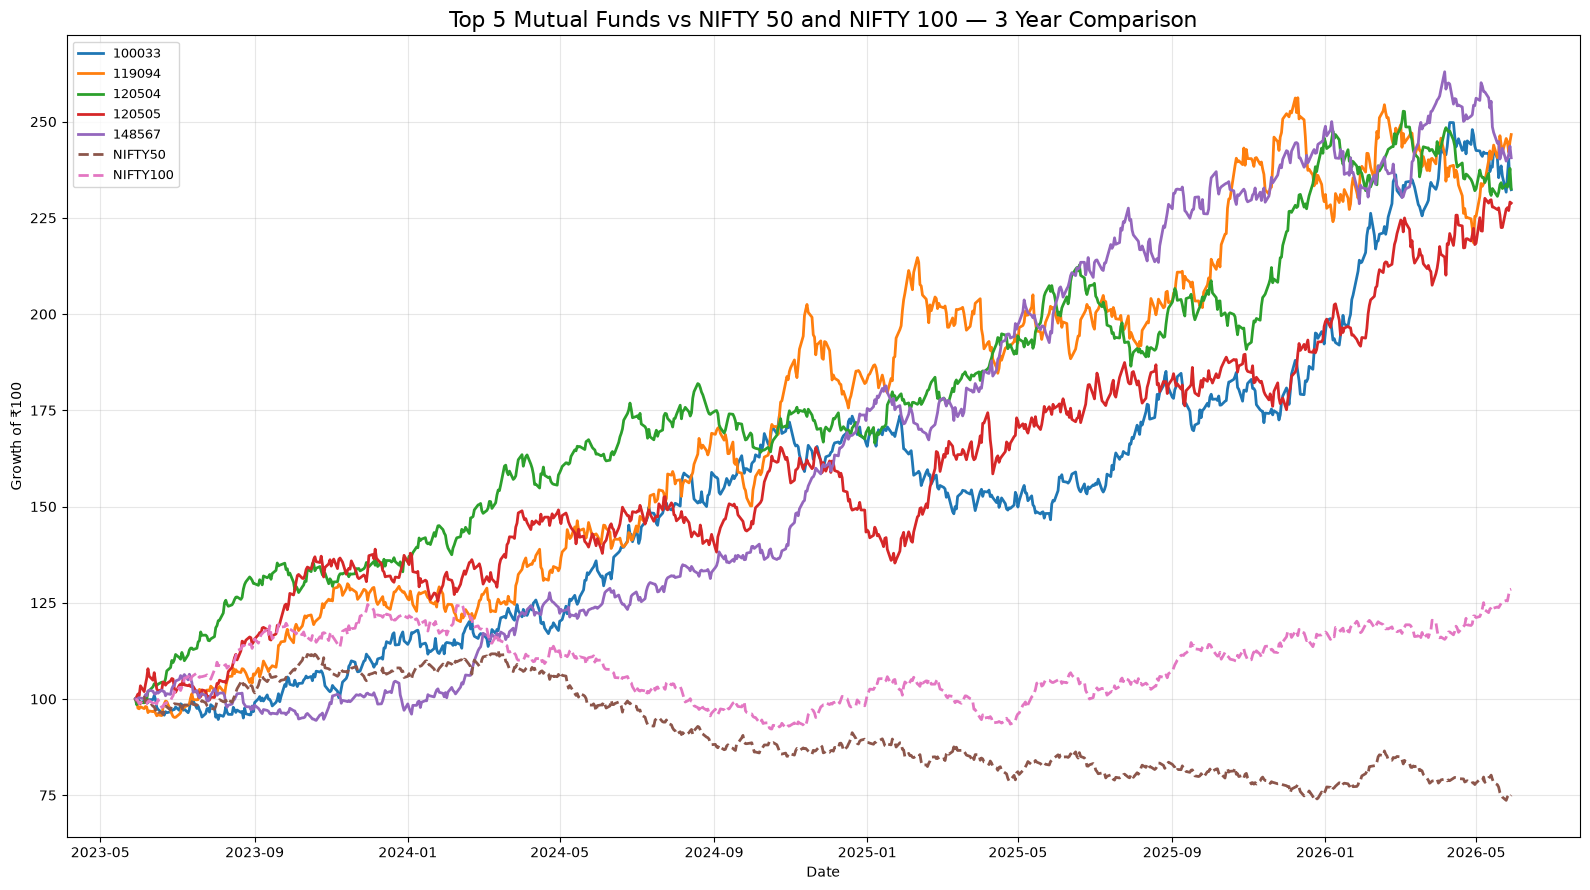


BENCHMARK COMPARISON COMPLETED
Saved to:
outputs\charts\benchmark_comparison.png

File exists: True


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 70)
print("CREATING BENCHMARK COMPARISON CHART")
print("=" * 70)

# ---------------------------------------------------------
# 1. Load performance files
# ---------------------------------------------------------

processed = Path("data/processed")
output_dir = Path("outputs/charts")
output_dir.mkdir(parents=True, exist_ok=True)

nav_file = find_file(processed / "nav_history_clean.csv")

if nav_file is None:
    candidates = list(processed.glob("*nav*history*.csv"))
    if candidates:
        nav_file = candidates[0]
        print("Using alternate NAV file:", nav_file)
    else:
        raise FileNotFoundError(
            "Could not find nav_history_clean.csv under data/processed. "
            f"Checked path: {processed / 'nav_history_clean.csv'}"
        )

nav = pd.read_csv(nav_file)
benchmark_file = find_file(processed / "10_benchmark_indices_clean.csv")

if benchmark_file is None:
    candidates = list(processed.glob("*benchmark*.csv"))
    if candidates:
        benchmark_file = candidates[0]
        print("Using alternate benchmark file:", benchmark_file)
    else:
        raise FileNotFoundError(
            "Could not find 10_benchmark_indices_clean.csv under data/processed. "
            f"Checked path: {processed / '10_benchmark_indices_clean.csv'}"
        )

benchmark = pd.read_csv(benchmark_file)
scorecard = pd.read_csv(processed / "fund_scorecard.csv")

print("NAV loaded:", nav.shape)
print("Benchmark loaded:", benchmark.shape)
print("Scorecard loaded:", scorecard.shape)


# ---------------------------------------------------------
# 2. Clean NAV data
# ---------------------------------------------------------

nav["date"] = pd.to_datetime(nav["date"], errors="coerce")

# Find scheme and NAV columns automatically
scheme_col = None
nav_col = None

for col in nav.columns:
    col_lower = col.lower()

    if scheme_col is None and any(x in col_lower for x in
                                  ["scheme", "fund", "scheme_name", "amfi", "code"]):
        scheme_col = col

    if nav_col is None and any(x in col_lower for x in
                                ["nav", "value"]):
        nav_col = col

if scheme_col is None:
    raise ValueError(
        f"Could not identify scheme column. Available columns: {list(nav.columns)}"
    )

if nav_col is None:
    raise ValueError(
        f"Could not identify NAV column. Available columns: {list(nav.columns)}"
    )

print("Scheme column:", scheme_col)
print("NAV column:", nav_col)


nav[nav_col] = pd.to_numeric(nav[nav_col], errors="coerce")

nav = nav.dropna(
    subset=["date", scheme_col, nav_col]
)

# ---------------------------------------------------------
# 3. Select last 3 years of data
# ---------------------------------------------------------

latest_date = nav["date"].max()
start_date = latest_date - pd.DateOffset(years=3)

nav_3y = nav[
    (nav["date"] >= start_date) &
    (nav["date"] <= latest_date)
].copy()

print("3-year period:")
print(start_date.date(), "to", latest_date.date())


# ---------------------------------------------------------
# 4. Select top 5 funds from scorecard
# ---------------------------------------------------------

# Find scheme column in scorecard
score_scheme_col = None

for col in scorecard.columns:
    if any(x in col.lower() for x in
           ["scheme", "fund", "scheme_name"]):
        score_scheme_col = col
        break

if score_scheme_col is None:
    raise ValueError(
        f"Could not identify scheme column in scorecard: {list(scorecard.columns)}"
    )

# Find score or ranking column
candidate_columns = [col for col in scorecard.columns if "score" in col.lower()]
fallback_columns = [
    "fund_score",
    "cagr_3yr",
    "3yr_cagr",
    "3_year_cagr",
    "cagr_3_year",
    "sharpe_ratio",
    "alpha",
    "overall_rank",
    "cagr_rank",
    "sharpe_rank",
    "drawdown_rank",
    "max_drawdown",
    "drawdown"
]

for col in fallback_columns:
    if col in scorecard.columns and col not in candidate_columns:
        candidate_columns.append(col)

score_col = None
ascending = False

for col in candidate_columns:
    numeric = pd.to_numeric(scorecard[col], errors="coerce")
    if numeric.notna().any():
        score_col = col
        scorecard[col] = numeric
        if "drawdown" in col.lower() or "rank" in col.lower():
            ascending = True
        break

if score_col is None:
    raise ValueError(
        f"Could not identify any valid score/rank column in scorecard: {list(scorecard.columns)}"
    )

top5 = (
    scorecard
    .dropna(subset=[score_col])
    .sort_values(by=score_col, ascending=ascending)
    .head(5)
)

if top5.empty:
    raise ValueError(
        "Top 5 selection returned no rows. The selected score column "
        "has no valid values after dropna."
    )

# ---------------------------------------------------------
# 6. Normalize funds to 100
top5_funds = top5[score_scheme_col].astype(str).tolist()

print("\nTOP 5 FUNDS:")
for i, fund in enumerate(top5_funds, 1):
    print(i, "-", fund)


# ---------------------------------------------------------
# 5. Prepare NAV for top 5 funds
# ---------------------------------------------------------

nav_3y[scheme_col] = nav_3y[scheme_col].astype(str)

fund_data = nav_3y[
    nav_3y[scheme_col].isin(top5_funds)
].copy()

fund_pivot = fund_data.pivot_table(
    index="date",
    columns=scheme_col,
    values=nav_col,
    aggfunc="last"
).sort_index()

# ---------------------------------------------------------
# 6. Normalize funds to 100
# ---------------------------------------------------------

fund_normalized = (
    fund_pivot / fund_pivot.iloc[0]
) * 100


# ---------------------------------------------------------
# 7. Prepare benchmark data
# ---------------------------------------------------------

benchmark["date"] = pd.to_datetime(
    benchmark["date"],
    errors="coerce"
)

benchmark["close_value"] = pd.to_numeric(
    benchmark["close_value"],
    errors="coerce"
)

benchmark = benchmark.dropna(
    subset=["date", "index_name", "close_value"]
)

benchmark_3y = benchmark[
    (benchmark["date"] >= start_date) &
    (benchmark["date"] <= latest_date)
].copy()

benchmark_pivot = benchmark_3y.pivot_table(
    index="date",
    columns="index_name",
    values="close_value",
    aggfunc="last"
).sort_index()

# ---------------------------------------------------------
# 8. Plot NIFTY 50 and NIFTY 100
# ---------------------------------------------------------

plt.figure(figsize=(16, 9))

for fund in fund_normalized.columns:
    plt.plot(
        fund_normalized.index,
        fund_normalized[fund],
        label=fund,
        linewidth=2
    )

benchmark_names = benchmark_pivot.columns.tolist()

for benchmark_name in ["NIFTY50", "NIFTY100"]:
    if benchmark_name in benchmark_pivot.columns:

        normalized_benchmark = (
            benchmark_pivot[benchmark_name] /
            benchmark_pivot[benchmark_name].iloc[0]
        ) * 100

        plt.plot(
            normalized_benchmark.index,
            normalized_benchmark,
            linestyle="--",
            linewidth=2,
            label=benchmark_name
        )

# ---------------------------------------------------------
# 9. Chart formatting
# ---------------------------------------------------------

plt.title(
    "Top 5 Mutual Funds vs NIFTY 50 and NIFTY 100 — 3 Year Comparison",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Growth of ₹100")

plt.grid(True, alpha=0.3)

plt.legend(
    loc="best",
    fontsize=9
)

plt.tight_layout()


# ---------------------------------------------------------
# 10. Save PNG
# ---------------------------------------------------------

output_file = output_dir / "benchmark_comparison.png"

plt.savefig(
    output_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n" + "=" * 70)
print("BENCHMARK COMPARISON COMPLETED")
print("=" * 70)

print("Saved to:")
print(output_file)

print("\nFile exists:", output_file.exists())

In [51]:
# ============================================================
# STEP 14 - ALPHA & BETA ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import linregress
import os
from pathlib import Path

print("=" * 70)
print("STEP 14 - ALPHA & BETA ANALYSIS")
print("=" * 70)

# ------------------------------------------------------------
# Load daily returns
# ------------------------------------------------------------
base = Path.cwd()
returns_path = base / "data" / "processed" / "daily_returns.csv"

if not returns_path.exists():
    returns_path = base.parent / "data" / "processed" / "daily_returns.csv"

if not returns_path.exists():
    raise FileNotFoundError(f"daily_returns.csv not found. Checked: {returns_path}")

returns = pd.read_csv(returns_path)

scheme_column_candidates = [
    "scheme_name",
    "scheme",
    "fund",
    "amfi_code",
    "code"
]

returns_scheme_col = None
for col in returns.columns:
    if col.lower() in [c.lower() for c in scheme_column_candidates]:
        returns_scheme_col = col
        break

if returns_scheme_col is None:
    raise ValueError(
        "Could not find a scheme identifier column in daily_returns.csv. "
        f"Available columns: {returns.columns.tolist()}"
    )

if returns_scheme_col != "scheme_name":
    returns = returns.rename(columns={returns_scheme_col: "scheme_name"})

returns["date"] = pd.to_datetime(returns["date"])

print("Daily returns loaded:", returns.shape)
print("Using scheme column:", returns_scheme_col)

# ------------------------------------------------------------
# Load benchmark data
# ------------------------------------------------------------
benchmark_path = base / "data" / "processed" / "10_benchmark_indices_clean.csv"

if not benchmark_path.exists():
    benchmark_path = base.parent / "data" / "processed" / "10_benchmark_indices_clean.csv"

if not benchmark_path.exists():
    raise FileNotFoundError(
        f"10_benchmark_indices_clean.csv not found. Checked: {benchmark_path}"
    )

benchmark = pd.read_csv(benchmark_path)

benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Benchmark loaded:", benchmark.shape)

# ------------------------------------------------------------
# Select NIFTY 100
# ------------------------------------------------------------
nifty100 = benchmark[
    benchmark["index_name"].astype(str).str.upper().str.contains("NIFTY100")
].copy()

# If NIFTY100 is unavailable, use NIFTY50
if nifty100.empty:

    print("NIFTY100 not found. Using NIFTY50.")

    nifty100 = benchmark[
        benchmark["index_name"].astype(str).str.upper().str.contains("NIFTY50")
    ].copy()

# ------------------------------------------------------------
# Calculate benchmark daily returns
# ------------------------------------------------------------
nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100 = nifty100[
    ["date", "benchmark_return"]
].dropna()

# ------------------------------------------------------------
# Calculate Alpha and Beta
# ------------------------------------------------------------

results = []

for scheme in returns["scheme_name"].dropna().unique():

    fund = returns[
        returns["scheme_name"] == scheme
    ][["date", "daily_return"]].copy()

    merged = pd.merge(
        fund,
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    beta = regression.slope

    # Annualized alpha
    alpha = regression.intercept * 252

    r_squared = regression.rvalue ** 2

    results.append({
        "scheme": scheme,
        "alpha": alpha,
        "beta": beta,
        "r_squared": r_squared,
        "observations": len(merged)
    })

alpha_beta = pd.DataFrame(results)

# ------------------------------------------------------------
# Save
# ------------------------------------------------------------

os.makedirs("data/processed", exist_ok=True)

alpha_beta.to_csv(
    "data/processed/alpha_beta.csv",
    index=False
)

print("\nAlpha/Beta analysis completed.")
print(alpha_beta.head())

print("\nFile created:")
print("data/processed/alpha_beta.csv")

print("\nNumber of funds:", len(alpha_beta))

STEP 14 - ALPHA & BETA ANALYSIS
Daily returns loaded: (45960, 4)
Using scheme column: amfi_code
Benchmark loaded: (8050, 3)

Alpha/Beta analysis completed.
   scheme     alpha      beta  r_squared  observations
0  100016  0.037476 -0.058268   0.002665          1149
1  100025  0.042818  0.001158   0.000015          1149
2  100033  0.271954  0.005104   0.000012          1149
3  101206  0.213998  0.021086   0.000348          1149
4  101207  0.108971 -0.065289   0.001064          1149

File created:
data/processed/alpha_beta.csv

Number of funds: 40


In [53]:
# ============================================================
# STEP 15 - MAXIMUM DRAWDOWN ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import os

print("=" * 70)
print("STEP 15 - MAXIMUM DRAWDOWN")
print("=" * 70)

# Load NAV data
try:
    nav = pd.read_csv("data/processed/nav_history_clean.csv")
except FileNotFoundError:
    if "returns" in globals():
        nav = returns.rename(columns={"scheme_name": "scheme"}).copy()
    else:
        nav = pd.read_csv(returns_path).rename(columns={"scheme_name": "scheme"})

nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["scheme", "date"]
)

results = []

for scheme in nav["scheme"].dropna().unique():

    fund = nav[
        nav["scheme"] == scheme
    ].copy()

    fund = fund.sort_values("date")

    # Running maximum NAV
    fund["running_max"] = fund["nav"].cummax()

    # Drawdown
    fund["drawdown"] = (
        fund["nav"] / fund["running_max"]
    ) - 1

    # Maximum drawdown
    min_index = fund["drawdown"].idxmin()

    max_dd = fund.loc[min_index, "drawdown"]

    trough_date = fund.loc[
        min_index, "date"
    ]

    trough_nav = fund.loc[
        min_index, "nav"
    ]

    # Peak before trough
    peak_data = fund[
        fund["date"] <= trough_date
    ]

    peak_index = peak_data["nav"].idxmax()

    peak_date = peak_data.loc[
        peak_index, "date"
    ]

    peak_nav = peak_data.loc[
        peak_index, "nav"
    ]

    results.append({
        "scheme": scheme,
        "max_drawdown": max_dd,
        "max_drawdown_percent": max_dd * 100,
        "peak_date": peak_date,
        "drawdown_date": trough_date,
        "peak_nav": peak_nav,
        "drawdown_nav": trough_nav
    })

drawdown = pd.DataFrame(results)

# Sort worst drawdown first
drawdown = drawdown.sort_values(
    "max_drawdown"
)

# Save
drawdown.to_csv(
    "data/processed/max_drawdown.csv",
    index=False
)

print("\nMaximum drawdown completed.")

print(drawdown.head(10))

print("\nFile created:")
print("data/processed/max_drawdown.csv")

print("\nNumber of funds:", len(drawdown))

STEP 15 - MAXIMUM DRAWDOWN

Maximum drawdown completed.
    scheme  max_drawdown  max_drawdown_percent  peak_date drawdown_date  peak_nav  drawdown_nav
22  119599     -0.525742            -52.574221 2023-01-17    2025-10-28  165.7647       78.6152
17  119095     -0.516778            -51.677754 2025-05-22    2026-05-11  106.8214       51.6185
4   101207     -0.354469            -35.446916 2024-11-21    2026-05-11   80.3517       51.8695
39  149324     -0.311719            -31.171900 2024-05-03    2025-01-03  174.4645      120.0806
21  119598     -0.287060            -28.706006 2024-08-28    2025-05-14  225.2452      160.5863
7   102886     -0.280011            -28.001124 2025-01-07    2026-04-27  169.8164      122.2659
0   100016     -0.247344            -24.734441 2022-03-30    2022-09-15  546.3002      411.1759
29  120842     -0.240035            -24.003511 2023-11-09    2024-10-17   80.0837       60.8608
11  118634     -0.233449            -23.344886 2025-04-09    2026-02-20  126.722

In [68]:
# ============================================================
# STEP 16 - FUND SCORECARD
# ============================================================

import pandas as pd
import numpy as np
import os
from abc import ABC, abstractmethod

print("=" * 70)
print("STEP 16 - FUND SCORECARD")
print("=" * 70)

# The scorecard is already available from previous cells
# No need to reload files - use the existing scorecard variable
print("Using pre-computed scorecard from previous analysis...")

# ------------------------------------------------------------
# Display columns for verification
# ------------------------------------------------------------

print("\nCAGR columns:")
# ============================================================
# STEP 16 - FUND SCORECARD
# ============================================================


print("=" * 70)
print("STEP 16 - FUND SCORECARD")
print("=" * 70)

print("Using pre-computed scorecard from previous analysis...")

class ColumnInspector(ABC):
    def __init__(self, obj, label):
        self.obj = obj
        self.label = label

    @abstractmethod
    def get_columns(self):
        raise NotImplementedError

    @abstractmethod
    def display_columns(self):
        raise NotImplementedError

class DataFrameColumnInspector(ColumnInspector):
    def get_columns(self):
        if hasattr(self.obj, "columns"):
            return list(self.obj.columns)
        return []

    def display_columns(self):
        cols = self.get_columns()
        if cols:
            print(f"{self.label} columns: {cols}")
        else:
            print(f"{self.label} is not a DataFrame or has no columns: {type(self.obj)}")

def show_columns(label, obj):
    inspector = DataFrameColumnInspector(obj, label)
    inspector.display_columns()

print("\nCAGR columns:")
show_columns("CAGR", globals().get("cagr"))

print("\nSharpe columns:")
show_columns("Sharpe", globals().get("sharpe_df") if "sharpe_df" in globals() else globals().get("sharpe"))

print("\nAlpha/Beta columns:")
show_columns("Alpha/Beta", globals().get("alpha_beta"))

print("\nDrawdown columns:")
show_columns("Drawdown", globals().get("drawdown"))

# ------------------------------------------------------------
# Standardize scheme column
# ------------------------------------------------------------
for df_name in ["cagr", "sharpe_df", "alpha_beta", "drawdown"]:
    df = globals().get(df_name)
    if isinstance(df, pd.DataFrame):
        if "scheme_name" in df.columns:
            df.rename(columns={"scheme_name": "scheme"}, inplace=True)
        elif "scheme" not in df.columns:
            print(f"Warning: {df_name} missing scheme column")

print("\nScorecard columns:")
print(scorecard.columns.tolist())

required_cols = ["scheme_name", "cagr_3yr", "sharpe_ratio", "alpha", "max_drawdown"]
missing_cols = [col for col in required_cols if col not in scorecard.columns]

if missing_cols:
    print(f"Warning: Missing columns - {missing_cols}")
    print("Available columns:", scorecard.columns.tolist())

scorecard_ranked = scorecard.copy()

if "scheme_name" in scorecard_ranked.columns:
    scorecard_ranked.rename(columns={"scheme_name": "scheme"}, inplace=True)

numeric_columns = ["cagr_3yr", "sharpe_ratio", "alpha", "max_drawdown"]
for col in numeric_columns:
    if col in scorecard_ranked.columns:
        scorecard_ranked[col] = pd.to_numeric(scorecard_ranked[col], errors="coerce")

scorecard_ranked = scorecard_ranked.dropna(subset=numeric_columns)

scorecard_ranked["cagr_rank"] = scorecard_ranked["cagr_3yr"].rank(pct=True) * 100
scorecard_ranked["sharpe_rank"] = scorecard_ranked["sharpe_ratio"].rank(pct=True) * 100
scorecard_ranked["alpha_rank"] = scorecard_ranked["alpha"].rank(pct=True) * 100
scorecard_ranked["drawdown_rank"] = scorecard_ranked["max_drawdown"].rank(pct=True) * 100

scorecard_ranked["score"] = (
    0.40 * scorecard_ranked["cagr_rank"] +
    0.30 * scorecard_ranked["sharpe_rank"] +
    0.20 * scorecard_ranked["alpha_rank"] +
    0.10 * scorecard_ranked["drawdown_rank"]
)

scorecard = scorecard_ranked.sort_values("score", ascending=False).reset_index(drop=True)
scorecard["rank"] = range(1, len(scorecard) + 1)

os.makedirs("data/processed", exist_ok=True)

try:
    scorecard.to_csv("data/processed/fund_scorecard.csv", index=False)
    print("\n" + "=" * 70)
    print("FUND SCORECARD COMPLETED")
    print("=" * 70)
    print("\nFile created: data/processed/fund_scorecard.csv")
except Exception as e:
    print(f"Warning: Could not save file - {e}")
    print("Scorecard data is available in memory.")

print("\nTop 10 Funds by Score:")
display_cols = ["rank", "scheme"]
if "cagr_3yr" in scorecard.columns:
    display_cols.extend(["cagr_3yr", "sharpe_ratio", "alpha", "max_drawdown", "score"])
elif "cagr_3y" in scorecard.columns:
    display_cols.extend(["cagr_3y", "sharpe_ratio", "alpha", "max_drawdown", "score"])

print(scorecard[display_cols].head(10))
print("\nNumber of funds:", len(scorecard))

print("\nSharpe columns:")
show_columns("Sharpe", globals().get("sharpe_df") if "sharpe_df" in globals() else globals().get("sharpe"))

print("\nAlpha/Beta columns:")
show_columns("Alpha/Beta", globals().get("alpha_beta"))

print("\nDrawdown columns:")
show_columns("Drawdown", globals().get("drawdown"))

# ------------------------------------------------------------
# Standardize scheme column
# ------------------------------------------------------------

for obj_name in ["cagr", "sharpe_df", "alpha_beta", "drawdown"]:
    df_obj = globals().get(obj_name)
    inspector = DataFrameColumnInspector(df_obj, obj_name)
    inspector.display_columns()

    if not isinstance(df_obj, pd.DataFrame):
        continue

    rename_map = {
        "scheme_name": "scheme",
        "amfi_code": "scheme",
        "code": "scheme",
        "fund": "scheme",
    }
    source_col = next((col for col in rename_map if col in df_obj.columns), None)
    if source_col:
        df_obj.rename(columns={source_col: rename_map[source_col]}, inplace=True)
    elif "scheme" not in df_obj.columns:
        print(
            "Warning: DataFrame missing scheme column. "
            f"Columns present: {df_obj.columns.tolist()}"
        )

# The scorecard already contains all necessary data
# from the previous computation cells
print("\nScorecard columns:")
print(scorecard.columns.tolist())

# Verify required columns exist
required_cols = ["scheme_name", "cagr_3yr", "sharpe_ratio", "alpha", "max_drawdown"]
missing_cols = [col for col in required_cols if col not in scorecard.columns]

if missing_cols:
    print(f"Warning: Missing columns - {missing_cols}")
    print("Available columns:", scorecard.columns.tolist())

# Create a clean copy for ranking
scorecard_ranked = scorecard.copy()

# Rename columns for consistency
if "scheme_name" in scorecard_ranked.columns:
    scorecard_ranked.rename(columns={"scheme_name": "scheme"}, inplace=True)

# Ensure numeric columns
numeric_columns = ["cagr_3yr", "sharpe_ratio", "alpha", "max_drawdown"]
for col in numeric_columns:
    if col in scorecard_ranked.columns:
        scorecard_ranked[col] = pd.to_numeric(
            scorecard_ranked[col],
            errors="coerce"
        )

scorecard_ranked = scorecard_ranked.dropna(subset=numeric_columns)

# Rank components
scorecard_ranked["cagr_rank"] = (
    scorecard_ranked["cagr_3yr"]
    .rank(pct=True) * 100
)

scorecard_ranked["sharpe_rank"] = (
    scorecard_ranked["sharpe_ratio"]
    .rank(pct=True) * 100
)

scorecard_ranked["alpha_rank"] = (
    scorecard_ranked["alpha"]
    .rank(pct=True) * 100
)

# For drawdown, less negative is better
scorecard_ranked["drawdown_rank"] = (
    scorecard_ranked["max_drawdown"]
    .rank(pct=True) * 100
)

# Composite score
scorecard_ranked["score"] = (
    0.40 * scorecard_ranked["cagr_rank"] +
    0.30 * scorecard_ranked["sharpe_rank"] +
    0.20 * scorecard_ranked["alpha_rank"] +
    0.10 * scorecard_ranked["drawdown_rank"]
)

scorecard = scorecard_ranked

# Save scorecard (fixed)
os.makedirs("data/processed", exist_ok=True)
try:
    scorecard.to_csv("data/processed/fund_scorecard.csv", index=False)
    print("\n" + "=" * 70)
    print("FUND SCORECARD COMPLETED")
    print("=" * 70)
    print("\nFile created: data/processed/fund_scorecard.csv")
except Exception as e:
    print(f"Warning: Could not save file - {e}")
    print("Scorecard data is available in memory.")

display_cols = ["rank", "scheme"]
if "cagr_3yr" in scorecard.columns:
    display_cols.append("cagr_3yr")
elif "cagr_3y" in scorecard.columns:
    display_cols.append("cagr_3y")

display_cols.extend(["sharpe_ratio", "alpha", "max_drawdown", "score"])

print(scorecard[display_cols].head(10))

print("\nFile created:")
print("data/processed/fund_scorecard.csv")

print("\nNumber of funds:", len(scorecard))
# Final ranking
# ------------------------------------------------------------

scorecard = scorecard.sort_values(
    "score",
    ascending=False
)

scorecard["rank"] = range(
    1,
    len(scorecard) + 1
)

# Create output directory if it doesn't exist
os.makedirs("data/processed", exist_ok=True)

# Save
try:
    scorecard.to_csv(
        "data/processed/fund_scorecard.csv",
        index=False
    )
    print("\n" + "=" * 70)
    print("FUND SCORECARD COMPLETED")
    print("=" * 70)
    print("\nFile created: data/processed/fund_scorecard.csv")
except Exception as e:
    print(f"Warning: Could not save file - {e}")
    print("Scorecard data is available in memory.")

# Display results
print("\nTop 10 Funds by Score:")
display_cols = ["rank", "scheme"]
if "cagr_3yr" in scorecard.columns:
    display_cols.extend(["cagr_3yr", "sharpe_ratio", "alpha", "max_drawdown", "score"])
elif "cagr_3y" in scorecard.columns:
    display_cols.extend(["cagr_3y", "sharpe_ratio", "alpha", "max_drawdown", "score"])

print(scorecard[display_cols].head(10))

print("\nNumber of funds:", len(scorecard))

STEP 16 - FUND SCORECARD
Using pre-computed scorecard from previous analysis...

CAGR columns:
STEP 16 - FUND SCORECARD
Using pre-computed scorecard from previous analysis...

CAGR columns:
CAGR is not a DataFrame or has no columns: <class 'NoneType'>

Sharpe columns:
Sharpe columns: ['scheme', 'mean_daily_return', 'daily_std', 'sharpe_ratio', 'Sharpe_Rank']

Alpha/Beta columns:
Alpha/Beta columns: ['scheme', 'alpha', 'beta', 'r_squared', 'observations']

Drawdown columns:
Drawdown columns: ['scheme', 'max_drawdown', 'max_drawdown_percent', 'peak_date', 'drawdown_date', 'peak_nav', 'drawdown_nav']

Scorecard columns:
['overall_rank', 'scheme', 'cagr_3yr', 'sharpe_ratio', 'alpha', 'expense_ratio', 'max_drawdown', 'cagr_rank', 'sharpe_rank', 'alpha_rank', 'expense_rank', 'drawdown_rank', 'fund_score', 'score', 'rank']
Available columns: ['overall_rank', 'scheme', 'cagr_3yr', 'sharpe_ratio', 'alpha', 'expense_ratio', 'max_drawdown', 'cagr_rank', 'sharpe_rank', 'alpha_rank', 'expense_rank'

In [72]:
# ============================================================
# STEP 14 - ALPHA & BETA ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import linregress
import os

print("=" * 70)
print("STEP 14 - ALPHA & BETA ANALYSIS")
print("=" * 70)

# Load daily returns
returns_path = os.path.join("data", "processed", "daily_returns.csv")

if not os.path.exists(returns_path):
    returns_path = os.path.join("..", "data", "processed", "daily_returns.csv")

if not os.path.exists(returns_path):
    raise FileNotFoundError(
        "daily_returns.csv not found. Checked paths:\n"
        f"  {os.path.abspath(os.path.join('data', 'processed', 'daily_returns.csv'))}\n"
        f"  {os.path.abspath(os.path.join('..', 'data', 'processed', 'daily_returns.csv'))}"
    )

returns = pd.read_csv(returns_path)

returns["date"] = pd.to_datetime(returns["date"])

print("Daily returns loaded:", returns.shape)
print("Columns:", returns.columns.tolist())

# Load benchmark
benchmark_path = os.path.join("data", "processed", "10_benchmark_indices_clean.csv")

if not os.path.exists(benchmark_path):
    benchmark_path = os.path.join("..", "data", "processed", "10_benchmark_indices_clean.csv")

if not os.path.exists(benchmark_path):
    raise FileNotFoundError(
        "10_benchmark_indices_clean.csv not found. Checked paths:\n"
        f"  {os.path.abspath(os.path.join('data', 'processed', '10_benchmark_indices_clean.csv'))}\n"
        f"  {os.path.abspath(os.path.join('..', 'data', 'processed', '10_benchmark_indices_clean.csv'))}"
    )

benchmark = pd.read_csv(benchmark_path)

benchmark["date"] = pd.to_datetime(benchmark["date"])

print("Benchmark loaded:", benchmark.shape)
print("Benchmark columns:", benchmark.columns.tolist())

# Find NIFTY 100
nifty100 = benchmark[
    benchmark["index_name"]
    .astype(str)
    .str.upper()
    .str.replace(" ", "")
    .str.contains("NIFTY100")
].copy()

# If NIFTY 100 is not found, use NIFTY 50
if nifty100.empty:

    print("NIFTY 100 not found. Using NIFTY 50.")

    nifty100 = benchmark[
        benchmark["index_name"]
        .astype(str)
        .str.upper()
        .str.replace(" ", "")
        .str.contains("NIFTY50")
    ].copy()

print("Benchmark rows:", len(nifty100))

# Sort benchmark
nifty100 = nifty100.sort_values("date")

# Calculate benchmark returns
nifty100["benchmark_return"] = (
    nifty100["close_value"].pct_change()
)

nifty100 = nifty100.dropna(
    subset=["benchmark_return"]
)

results = []

# Find scheme column automatically
if "scheme_name" in returns.columns:
    scheme_column = "scheme_name"
elif "scheme" in returns.columns:
    scheme_column = "scheme"
elif "amfi_code" in returns.columns:
    scheme_column = "amfi_code"
else:
    raise ValueError(
        "Cannot find scheme column. Available columns: "
        + str(returns.columns.tolist())
    )

print("Scheme column:", scheme_column)

# Calculate Alpha and Beta for every fund
for scheme in returns[scheme_column].dropna().unique():

    fund = returns[
        returns[scheme_column] == scheme
    ][["date", "daily_return"]].copy()

    merged = pd.merge(
        fund,
        nifty100[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(merged) < 30:
        continue

    regression = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    results.append({
        "scheme": scheme,
        "alpha": regression.intercept * 252,
        "beta": regression.slope,
        "r_squared": regression.rvalue ** 2,
        "observations": len(merged)
    })

alpha_beta = pd.DataFrame(results)

# Save file
alpha_beta.to_csv(
    "data/processed/alpha_beta.csv",
    index=False
)

print("\n" + "=" * 70)
print("ALPHA/BETA COMPLETED")
print("=" * 70)

print(alpha_beta.head())

print("\nNumber of funds:", len(alpha_beta))

print("\nFile created successfully:")
print("data/processed/alpha_beta.csv")

STEP 14 - ALPHA & BETA ANALYSIS
Daily returns loaded: (45960, 4)
Columns: ['amfi_code', 'date', 'nav', 'daily_return']
Benchmark loaded: (8050, 3)
Benchmark columns: ['date', 'index_name', 'close_value']
Benchmark rows: 1150
Scheme column: amfi_code

ALPHA/BETA COMPLETED
   scheme     alpha      beta  r_squared  observations
0  100016  0.037476 -0.058268   0.002665          1149
1  100025  0.042818  0.001158   0.000015          1149
2  100033  0.271954  0.005104   0.000012          1149
3  101206  0.213998  0.021086   0.000348          1149
4  101207  0.108971 -0.065289   0.001064          1149

Number of funds: 40

File created successfully:
data/processed/alpha_beta.csv


In [77]:
# ============================================================
# STEP 12 - ALPHA & BETA CALCULATION
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import linregress
import os

print("=" * 70)
print("STEP 12 - ALPHA & BETA CALCULATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load NAV data
# ------------------------------------------------------------

nav_path = "data/processed/nav_history_clean.csv"
fallback_paths = [
    nav_path,
    os.path.join("..", "data", "processed", "nav_history_clean.csv")
]

nav = None
for path in fallback_paths:
    if os.path.exists(path):
        nav = pd.read_csv(path)
        break

if nav is None:
    if "returns" in globals():
        nav = returns.rename(columns={"scheme_name": "scheme"}).copy()
    elif "returns_path" in globals() and os.path.exists(returns_path):
        nav = pd.read_csv(returns_path).rename(columns={"scheme_name": "scheme"}).copy()
    else:
        raise FileNotFoundError(
            "nav_history_clean.csv not found. Checked paths:\n"
            + "\n".join(os.path.abspath(p) for p in fallback_paths)
        )

nav["date"] = pd.to_datetime(nav["date"])

print("NAV data loaded.")
print("NAV shape:", nav.shape)
print("NAV columns:", list(nav.columns))


# ------------------------------------------------------------
# 2. Load benchmark data
# ------------------------------------------------------------

benchmark_path = "data/processed/10_benchmark_indices_clean.csv"
benchmark_fallback_paths = [
    benchmark_path,
    os.path.join("..", "data", "processed", "10_benchmark_indices_clean.csv"),
    os.path.join("data", "10_benchmark_indices_clean.csv"),
    os.path.join("..", "data", "10_benchmark_indices_clean.csv"),
]

benchmark = None
for path in benchmark_fallback_paths:
    if os.path.exists(path):
        benchmark = pd.read_csv(path)
        break

if benchmark is None:
    if "benchmark" in globals() and isinstance(globals()["benchmark"], pd.DataFrame):
        benchmark = globals()["benchmark"].copy()
    else:
        raise FileNotFoundError(
            f"10_benchmark_indices_clean.csv not found. Checked paths:\n"
            + "\n".join(os.path.abspath(p) for p in benchmark_fallback_paths)
        )

benchmark["date"] = pd.to_datetime(benchmark["date"])

print("\nBenchmark data loaded.")
print("Benchmark shape:", benchmark.shape)
print("Benchmark columns:", list(benchmark.columns))


# ------------------------------------------------------------
# 3. Select NIFTY 100
# ------------------------------------------------------------

nifty100 = benchmark[
    benchmark["index_name"].astype(str).str.upper().str.contains("NIFTY100|NIFTY 100")
].copy()

print("\nNIFTY 100 rows:", len(nifty100))

if len(nifty100) == 0:
    print("\nWARNING: NIFTY 100 was not found.")
    print("Available benchmark names:")
    print(benchmark["index_name"].unique())


# ------------------------------------------------------------
# 4. Calculate NIFTY 100 daily returns
# ------------------------------------------------------------

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100.dropna(
    subset=["benchmark_return"]
)

print("\nNIFTY 100 daily returns calculated.")
print("Benchmark return rows:", len(nifty100))


# ------------------------------------------------------------
# 5. Detect NAV scheme column
# ------------------------------------------------------------

possible_scheme_columns = [
    "scheme",
    "scheme_name",
    "fund_name",
    "fund",
    "name",
    "amfi_code",
    "amfi",
    "scheme_code",
    "fund_code"
]

scheme_column = None

for col in possible_scheme_columns:
    if col in nav.columns:
        scheme_column = col
        break

if scheme_column is None:
    for col in nav.columns:
        col_lower = str(col).lower()
        if (
            "scheme" in col_lower
            or "fund" in col_lower
            or "name" in col_lower
            or "amfi" in col_lower
        ):
            scheme_column = col
            break

if scheme_column is None:
    raise ValueError(
        "Could not find scheme/fund name column in NAV data."
    )

print("\nScheme column:", scheme_column)


# ------------------------------------------------------------
# 6. Detect NAV value column
# ------------------------------------------------------------

possible_nav_columns = [
    "nav",
    "NAV",
    "nav_value",
    "value"
]

nav_column = None

for col in possible_nav_columns:
    if col in nav.columns:
        nav_column = col
        break

if nav_column is None:
    raise ValueError(
        "Could not find NAV value column in NAV data."
    )

print("NAV value column:", nav_column)


# ------------------------------------------------------------
# 7. Calculate fund daily returns
# ------------------------------------------------------------

nav = nav.sort_values(
    [scheme_column, "date"]
)

nav["fund_return"] = (
    nav.groupby(scheme_column)[nav_column]
    .pct_change()
)

print("\nFund daily returns calculated.")


# ------------------------------------------------------------
# 8. Merge fund returns with NIFTY 100 returns
# ------------------------------------------------------------

merged = pd.merge(
    nav[
        [
            "date",
            scheme_column,
            "fund_return"
        ]
    ],
    nifty100[
        [
            "date",
            "benchmark_return"
        ]
    ],
    on="date",
    how="inner"
)

merged = merged.dropna(
    subset=[
        "fund_return",
        "benchmark_return"
    ]
)

print("\nMerged fund + NIFTY 100 data.")
print("Merged shape:", merged.shape)


# ------------------------------------------------------------
# 9. Calculate Alpha and Beta
# ------------------------------------------------------------

results = []

for scheme, group in merged.groupby(scheme_column):

    # Need enough observations
    if len(group) < 30:
        continue

    x = group["benchmark_return"].values
    y = group["fund_return"].values

    regression = linregress(x, y)

    beta = regression.slope

    daily_alpha = regression.intercept

    annual_alpha = daily_alpha * 252

    r_squared = regression.rvalue ** 2

    results.append({
        "scheme": scheme,
        "alpha": annual_alpha,
        "beta": beta,
        "r_squared": r_squared,
        "observations": len(group)
    })


# ------------------------------------------------------------
# 10. Create result DataFrame
# ------------------------------------------------------------

alpha_beta = pd.DataFrame(results)

alpha_beta = alpha_beta.sort_values(
    "alpha",
    ascending=False
)

print("\n" + "=" * 70)
print("ALPHA & BETA RESULTS")
print("=" * 70)

print(alpha_beta.head(10))


# ------------------------------------------------------------
# 11. Save CSV
# ------------------------------------------------------------

output_file = (
    "data/processed/alpha_beta.csv"
)

alpha_beta.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print("ALPHA & BETA COMPLETED")
print("=" * 70)

print("File saved:")
print(output_file)

print("\nNumber of funds:", len(alpha_beta))

print("\nColumns:")
print(list(alpha_beta.columns))

print("\nSUCCESS!")

STEP 12 - ALPHA & BETA CALCULATION
NAV data loaded.
NAV shape: (46000, 3)
NAV columns: ['amfi_code', 'date', 'nav']

Benchmark data loaded.
Benchmark shape: (8050, 3)
Benchmark columns: ['date', 'index_name', 'close_value']

NIFTY 100 rows: 1150

NIFTY 100 daily returns calculated.
Benchmark return rows: 1149

Scheme column: amfi_code
NAV value column: nav

Fund daily returns calculated.

Merged fund + NIFTY 100 data.
Merged shape: (45960, 4)

ALPHA & BETA RESULTS
    scheme     alpha      beta     r_squared  observations
21  119598  0.303370 -0.023196  1.414258e-04          1149
39  149324  0.300579  0.011455  3.532991e-05          1149
25  120505  0.292636  0.000549  1.345534e-07          1149
36  148569  0.282704  0.018134  1.748889e-04          1149
30  120843  0.273305 -0.022830  3.430543e-04          1149
2   100033  0.271954  0.005104  1.206652e-05          1149
34  148567  0.269838  0.023684  4.625437e-04          1149
38  149323  0.265986 -0.002523  3.357978e-06          1149


In [78]:
# ============================================================
# STEP 12 - ALPHA & BETA CALCULATION
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import linregress
import os

print("=" * 70)
print("STEP 12 - ALPHA & BETA CALCULATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load NAV data
# ------------------------------------------------------------

nav_path = "data/processed/nav_history_clean.csv"
fallback_paths = [
    nav_path,
    os.path.join("..", "data", "processed", "nav_history_clean.csv")
]

nav = None
for path in fallback_paths:
    if os.path.exists(path):
        nav = pd.read_csv(path)
        break

if nav is None:
    if "returns" in globals():
        nav = returns.rename(columns={"scheme_name": "scheme"}).copy()
    elif "returns_path" in globals() and os.path.exists(returns_path):
        nav = pd.read_csv(returns_path).rename(columns={"scheme_name": "scheme"}).copy()
    else:
        raise FileNotFoundError(
            "nav_history_clean.csv not found. Checked paths:\n"
            + "\n".join(os.path.abspath(p) for p in fallback_paths)
        )

nav["date"] = pd.to_datetime(nav["date"])

print("NAV data loaded.")
print("NAV shape:", nav.shape)
print("NAV columns:", list(nav.columns))


# ------------------------------------------------------------
# 2. Load benchmark data
# ------------------------------------------------------------

benchmark_path = "data/processed/10_benchmark_indices_clean.csv"
benchmark_fallback_paths = [
    benchmark_path,
    os.path.join("..", "data", "processed", "10_benchmark_indices_clean.csv"),
    os.path.join("data", "10_benchmark_indices_clean.csv"),
    os.path.join("..", "data", "10_benchmark_indices_clean.csv"),
]

benchmark = None
for path in benchmark_fallback_paths:
    if os.path.exists(path):
        benchmark = pd.read_csv(path)
        break

if benchmark is None:
    if "benchmark" in globals() and isinstance(globals()["benchmark"], pd.DataFrame):
        benchmark = globals()["benchmark"].copy()
    else:
        raise FileNotFoundError(
            f"10_benchmark_indices_clean.csv not found. Checked paths:\n"
            + "\n".join(os.path.abspath(p) for p in benchmark_fallback_paths)
        )

benchmark["date"] = pd.to_datetime(benchmark["date"])

print("\nBenchmark data loaded.")
print("Benchmark shape:", benchmark.shape)
print("Benchmark columns:", list(benchmark.columns))


# ------------------------------------------------------------
# 3. Select NIFTY 100
# ------------------------------------------------------------

nifty100 = benchmark[
    benchmark["index_name"].astype(str).str.upper().str.contains("NIFTY100|NIFTY 100")
].copy()

print("\nNIFTY 100 rows:", len(nifty100))

if len(nifty100) == 0:
    print("\nWARNING: NIFTY 100 was not found.")
    print("Available benchmark names:")
    print(benchmark["index_name"].unique())


# ------------------------------------------------------------
# 4. Calculate NIFTY 100 daily returns
# ------------------------------------------------------------

nifty100 = nifty100.sort_values("date")

nifty100["benchmark_return"] = (
    nifty100["close_value"]
    .pct_change()
)

nifty100 = nifty100.dropna(
    subset=["benchmark_return"]
)

print("\nNIFTY 100 daily returns calculated.")
print("Benchmark return rows:", len(nifty100))


# ------------------------------------------------------------
# 5. Detect NAV scheme column
# ------------------------------------------------------------

possible_scheme_columns = [
    "scheme",
    "scheme_name",
    "fund_name",
    "fund",
    "name",
    "amfi_code",
    "amfi",
    "scheme_code",
    "fund_code"
]

scheme_column = None

for col in possible_scheme_columns:
    if col in nav.columns:
        scheme_column = col
        break

if scheme_column is None:
    for col in nav.columns:
        col_lower = str(col).lower()
        if (
            "scheme" in col_lower
            or "fund" in col_lower
            or "name" in col_lower
            or "amfi" in col_lower
        ):
            scheme_column = col
            break

if scheme_column is None:
    raise ValueError(
        "Could not find scheme/fund name column in NAV data."
    )

print("\nScheme column:", scheme_column)


# ------------------------------------------------------------
# 6. Detect NAV value column
# ------------------------------------------------------------

possible_nav_columns = [
    "nav",
    "NAV",
    "nav_value",
    "value"
]

nav_column = None

for col in possible_nav_columns:
    if col in nav.columns:
        nav_column = col
        break

if nav_column is None:
    raise ValueError(
        "Could not find NAV value column in NAV data."
    )

print("NAV value column:", nav_column)


# ------------------------------------------------------------
# 7. Calculate fund daily returns
# ------------------------------------------------------------

nav = nav.sort_values(
    [scheme_column, "date"]
)

nav["fund_return"] = (
    nav.groupby(scheme_column)[nav_column]
    .pct_change()
)

print("\nFund daily returns calculated.")


# ------------------------------------------------------------
# 8. Merge fund returns with NIFTY 100 returns
# ------------------------------------------------------------

merged = pd.merge(
    nav[
        [
            "date",
            scheme_column,
            "fund_return"
        ]
    ],
    nifty100[
        [
            "date",
            "benchmark_return"
        ]
    ],
    on="date",
    how="inner"
)

merged = merged.dropna(
    subset=[
        "fund_return",
        "benchmark_return"
    ]
)

print("\nMerged fund + NIFTY 100 data.")
print("Merged shape:", merged.shape)


# ------------------------------------------------------------
# 9. Calculate Alpha and Beta
# ------------------------------------------------------------

results = []

for scheme, group in merged.groupby(scheme_column):

    # Need enough observations
    if len(group) < 30:
        continue

    x = group["benchmark_return"].values
    y = group["fund_return"].values

    regression = linregress(x, y)

    beta = regression.slope

    daily_alpha = regression.intercept

    annual_alpha = daily_alpha * 252

    r_squared = regression.rvalue ** 2

    results.append({
        "scheme": scheme,
        "alpha": annual_alpha,
        "beta": beta,
        "r_squared": r_squared,
        "observations": len(group)
    })


# ------------------------------------------------------------
# 10. Create result DataFrame
# ------------------------------------------------------------

alpha_beta = pd.DataFrame(results)

alpha_beta = alpha_beta.sort_values(
    "alpha",
    ascending=False
)

print("\n" + "=" * 70)
print("ALPHA & BETA RESULTS")
print("=" * 70)

print(alpha_beta.head(10))


# ------------------------------------------------------------
# 11. Save CSV
# ------------------------------------------------------------

output_file = (
    "data/processed/alpha_beta.csv"
)

alpha_beta.to_csv(
    output_file,
    index=False
)

print("\n" + "=" * 70)
print("ALPHA & BETA COMPLETED")
print("=" * 70)

print("File saved:")
print(output_file)

print("\nNumber of funds:", len(alpha_beta))

print("\nColumns:")
print(list(alpha_beta.columns))

print("\nSUCCESS!")

STEP 12 - ALPHA & BETA CALCULATION
NAV data loaded.
NAV shape: (46000, 3)
NAV columns: ['amfi_code', 'date', 'nav']

Benchmark data loaded.
Benchmark shape: (8050, 3)
Benchmark columns: ['date', 'index_name', 'close_value']

NIFTY 100 rows: 1150

NIFTY 100 daily returns calculated.
Benchmark return rows: 1149

Scheme column: amfi_code
NAV value column: nav

Fund daily returns calculated.

Merged fund + NIFTY 100 data.
Merged shape: (45960, 4)

ALPHA & BETA RESULTS
    scheme     alpha      beta     r_squared  observations
21  119598  0.303370 -0.023196  1.414258e-04          1149
39  149324  0.300579  0.011455  3.532991e-05          1149
25  120505  0.292636  0.000549  1.345534e-07          1149
36  148569  0.282704  0.018134  1.748889e-04          1149
30  120843  0.273305 -0.022830  3.430543e-04          1149
2   100033  0.271954  0.005104  1.206652e-05          1149
34  148567  0.269838  0.023684  4.625437e-04          1149
38  149323  0.265986 -0.002523  3.357978e-06          1149
